# Stage 9: Document Search


### Project Structure

```bash
CS5246Project/
    │
    ├─ data/
    │   ├─ inverted_index/
    │   │   ├─ inverted_index_tfidf_titles.json
    │   │   └─ inverted_index_tfidf_fulltext.json
    │   │
    │   ├─ models/
    │   │   ├─ sentence_bert_model/
    │   │   ├─ bm25_comments_model.joblib
    │   │   ├─ bm25_fulltext_model.joblib
    │   │   ├─ bm25_titles_model.joblib
    │   │   ├─ tfidf_comments_vectorizer.joblib
    │   │   └─ tfidf_posts_vectorizer.joblib
    │   │
    │   ├─ vector_database/
    │   │   ├─ bert_comments_embeddings.npy
    │   │   ├─ bert_contents_embeddings.npy
    │   │   ├─ bert_fulltext_embeddings.npy
    │   │   ├─ bert_titles_embeddings.npy
    │   │   ├─ bm25_comments.npz
    │   │   ├─ bm25_contents.npz
    │   │   ├─ bm25_fulltext.npz
    │   │   ├─ bm25_titles.npz
    │   │   ├─ tfidf_comments.npz
    │   │   ├─ tfidf_contents.npz
    │   │   ├─ tfidf_fulltext.npz
    │   │   └─ tfidf_titles.npz
    │   │
    │   ├─ PostVault.csv
    │   ├─ CommentVault.csv
    │   └─ raw_data/
    │
    ├─ sentiment_plots/
    │   ├─ emotion_plots/
    │   ├─ emotion_dashboard.py
    │   └─ plot_emotion_summary.py
    │
    ├─ Stage_0_Introduction.ipynb                       
    ├─ Stage_1_Data_Collection_and_Data_Cleaning.ipynb
    ├─ Stage_2_POS_and_NER_Tagging.ipynb
    ├─ Stage_3_Singlish_Normalisation.ipynb
    ├─ Stage_4_Singlish_to_English_Conversion.ipynb     
    ├─ Stage_5_Common_Normalisation.ipynb
    ├─ Stage_6_Vector_Space_Model_and_Inverted_Index.ipynb
    ├─ Stage_7_Sentiment_Analysis.ipynb
    ├─ Stage_8_Clustering_and_Visualization.ipynb       
-----------------------------------------------------------------
│   ├─ Stage_9_Document_Search.ipynb                            │
-----------------------------------------------------------------
    └─ utilities/
        │
        ├─ pp_class.py
        ├─ singlish_dictionary.json
        ├─ singlish_regex_to_text.txt
        └─ slang_dictionary.csv
```

## To access the mounted folder directly.

### Step 1: Add the Shared Folder to your Google Drive (if you haven't already)

1.  **Open Google Drive** (drive.google.com) in your web browser.
2.  Go to the **'Shared with me'** section.
3.  Locate the folder that was shared with you.
4.  **Right-click** on the shared folder.
5.  Select **'Add shortcut to Drive'** (or 'Add to My Drive', depending on the interface). Choose a location within 'My Drive' if prompted, or simply add it to the root of 'My Drive'.

This creates a shortcut to the shared folder in your 'My Drive', making it accessible when Colab mounts your personal Drive.
### Step 2: Access the Shared Folder in Colab (No action needed)

Once your Drive is mounted, you can navigate to the shared folder. If you added a shortcut, it will appear in your 'My Drive' just like any other folder. The path will typically be `/content/gdrive/MyDrive/YourSharedFolderName`.

It should be able to run the script below already

In [1]:
# -----------
# Mount Drive
# -----------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dependencies

### Install Dependencies

In [2]:
!pip install emoji ftfy langdetect import-ipynb matplotlib seaborn wordcloud rank_bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e5e7a15737b735a38da99343dfc2c4caa40c30f749452c63d56741b862a35535
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


### Change Directory

In [3]:
# Path
# ----
FOLDER_PATH: str = "/content/drive/MyDrive/CS5246Project/"

import os
os.chdir(FOLDER_PATH)

### Import Essential Library

In [4]:
import re
import json
import joblib
import unittest
import numpy as np
import pandas as pd
import import_ipynb
import seaborn as sns
from tqdm import tqdm
from typing import Dict
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from Stage_2_POS_and_NER_Tagging import pos_tagger
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from Stage_0_Introduction import display_first_text_column_head, save_dfs_to_csv, output_base_dir, save_single_df_to_csv, vector_database_dir, models_dir, inverted_index_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Data

In [5]:
    # -------------------------------
# Load PostVault and CommentVault
# -------------------------------
df_posts = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/PostVault.csv', keep_default_na=False)
df_comments = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/CommentVault.csv', keep_default_na=False)

print("----------------------------------------------")
print("PostVault and CommentVault loaded successfully")
print("----------------------------------------------")

# --------------------
# Load TF-IDF Matrices
# --------------------
tfidf_titles = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_titles.npz')
tfidf_contents = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_contents.npz')
tfidf_full_text = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_fulltext.npz')

tfidf_comments = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_comments.npz')

# -------------------------------
# Load TfidfVectorizer Vectorizer
# -------------------------------
tfidf_posts_vectorizer = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/tfidf_posts_vectorizer.joblib')
tfidf_comments_vectorizer = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/tfidf_comments_vectorizer.joblib')

print("----------------------------------------------------------")
print("TfidfVectorizer for posts and comments loaded successfully")
print("----------------------------------------------------------")

# ------------------
# Load BM25 Matrices
# ------------------
bm25_titles = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_titles.npz')
bm25_contents = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_contents.npz')
bm25_full_text = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_fulltext.npz')

bm25_comments = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_comments.npz')

# ---------------
# Load BM25 Model
# ---------------
bm25_title_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_titles_model.joblib')
bm25_fulltext_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_fulltext_model.joblib')
bm25_comments_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_comments_model.joblib')

print("-----------------------------------------------")
print("BM25 for posts and comments loaded successfully")
print("-----------------------------------------------")

# --------------------
# Load Bert Embeddings
# --------------------
bert_titles = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_titles_embeddings.npy')
bert_contents = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_contents_embeddings.npy')
bert_full_text = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_fulltext_embeddings.npy')

bert_comments = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_comments_embeddings.npy')

# ---------------
# Load Bert Model
# ---------------
bert_model_path = os.path.join(models_dir, 'sentence_bert_model')
bert_model = SentenceTransformer(bert_model_path)

print("-----------------------------------------------")
print("Bert for posts and comments loaded successfully")
print("-----------------------------------------------")

# -------------------
# Load Inverted Index
# -------------------

inverted_index_titles_path = os.path.join(inverted_index_dir, 'inverted_index_tfidf_titles.json')
inverted_index_full_text_path = os.path.join(inverted_index_dir, 'inverted_index_tfidf_titles.json')

with open(inverted_index_titles_path, "r") as f:
    inverted_index_titles = json.load(f)

with open(inverted_index_full_text_path, "r") as f:
    inverted_index_full_text = json.load(f)

----------------------------------------------
PostVault and CommentVault loaded successfully
----------------------------------------------
----------------------------------------------------------
TfidfVectorizer for posts and comments loaded successfully
----------------------------------------------------------
-----------------------------------------------
BM25 for posts and comments loaded successfully
-----------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

-----------------------------------------------
Bert for posts and comments loaded successfully
-----------------------------------------------


## Centroid Tree Search

Future Optimization:
1. Multi-tree index (Annoy Centroid)
1. Vectorized beam search (10-30x faster)
1. Adaptive beam width
1. Batch query SIMD search

In [ ]:
class CentroidTreeSearch:
    class Node:
        """
        Represents a cluster (node) in the search tree.

        Attributes:
            centroid (np.ndarray): The mean vector of the cluster.
            indices (np.ndarray): Global data indices of points assigned to this node.
            level (int): Depth of the node in the tree (0 for root).
            children (list): List of child Node objects.
            centroid_matrix (np.ndarray): (K, D) matrix of children centroids for fast vectorized search (K=number of children).
        """
        def __init__(self, centroid=None, indices=None, level=0):
            self.centroid = centroid     # Mean vector of the cluster
            self.indices = indices       # Global data indices assigned to this node
            self.level = level           # Depth of the node in the tree
            self.children = []           # List of child Nodes
            self.centroid_matrix = None  # (K, D) matrix of children centroids for fast search

    def __init__(
        self,
        data,
        levels=2,
        branching_mode="fixed", # Options: "fixed", "balanced", "greedy"
        fixed_k=10,             # Custom branching factor for "fixed" mode
        max_k=35,               # Max clusters for "greedy" mode
        metric="euclidean",
        initial_labels=None     # ADDED: Optional pre-defined labels for the first level
    ):
        self.metric = metric
        # Normalize for cosine similarity so we can use dot product as a score
        self.data = self._normalize(data) if metric == "cosine" else data
        self.N, self.D = data.shape
        self.levels = levels
        self.branching_mode = branching_mode
        self.fixed_k = fixed_k
        self.max_k = max_k
        self.initial_labels = initial_labels # Store the labels
        self.root = None

        self._build_tree()

    def _normalize(self, x):
        norm = np.linalg.norm(x, axis=1, keepdims=True)
        return x / (norm + 1e-10)

    def _choose_k(self, subset_size):
        if self.branching_mode == "fixed":
            # Use the predefined fixed_k, ensuring it doesn't exceed the subset size
            return min(self.fixed_k, subset_size)

        elif self.branching_mode == "balanced":
            # Heuristic to distribute points evenly across levels: K = N^(1/L)
            # Calculates k such that (k^levels) is approximately N (total data points).
            k = int(np.ceil(subset_size ** (1 / self.levels)))
            # Ensure k is at least 2 for clustering and not excessively large
            return max(2, min(50, k))

        # Default case, though 'greedy' mode handles its own k selection
        return self.fixed_k

    def _build_tree(self):
        indices = np.arange(self.N)

        if self.initial_labels is not None:
            # Check for label length consistency
            if len(self.initial_labels) != self.N:
                raise ValueError("initial_labels length must match data size.")

            # Create root node at level 0
            root_centroid = np.mean(self.data, axis=0)
            self.root = self.Node(root_centroid, indices, 0)

            # Partition data based on provided labels for the first level
            unique_labels = np.unique(self.initial_labels)
            child_centroids = []

            for label in unique_labels:
                child_idx = indices[self.initial_labels == label]
                if len(child_idx) == 0: continue

                # Recursively build starting from level 1
                child_node = self._build_node(child_idx, level=1)
                self.root.children.append(child_node)
                child_centroids.append(child_node.centroid)

            # Optimization: Store first level centroids for search
            if self.root.children:
                self.root.centroid_matrix = np.vstack(child_centroids)
        else:
            # Standard automatic build
            self.root = self._build_node(indices, 0)

    def _build_node(self, indices, level):
        # Calculate the centroid for the current node's data points
        node_centroid = np.mean(self.data[indices], axis=0)
        node = self.Node(node_centroid, indices, level)

        # Base Case: stop recursion if max levels reached or cluster is too small to subdivide
        if level >= self.levels or len(indices) <= self.max_k:
            return node

        subset = self.data[indices] # Data points for clustering at this level

        # Decide K based on user settings (branching_mode)
        if self.branching_mode == "greedy":
            best_k, best_score = 2, -1.0
            # Iterate from 2 up to max_k (or current subset size) to find optimal k
            for ki in range(2, min(self.max_k + 1, len(indices))):
                km = KMeans(n_clusters=ki, n_init=3, random_state=42).fit(subset)
                # Calculate silhouette score, handling cases with single clusters or constant data
                if len(np.unique(km.labels_)) > 1: # Silhouette score requires at least 2 clusters
                    score = silhouette_score(subset, km.labels_)
                    if score > best_score:
                        best_score, best_k = score, ki
            k = best_k

        else:
            k = self._choose_k(len(indices)) # Use fixed or balanced k

        # If k is still too small (e.g., subset size is less than 2), stop dividing
        if k < 2:
            return node

        # Perform K-Means clustering on the subset of data points
        kmeans = KMeans(n_clusters=k, n_init=5, random_state=42).fit(subset)

        # Create child nodes based on KMeans results
        child_centroids = []
        for i in range(k):
            # Get global indices for data points assigned to the i-th cluster
            child_idx = indices[kmeans.labels_ == i]
            if len(child_idx) == 0: continue # Skip empty clusters

            # Recursively build the child node
            child = self._build_node(child_idx, level + 1)
            child.centroid = kmeans.cluster_centers_[i] # Assign the centroid from KMeans
            node.children.append(child)
            child_centroids.append(child.centroid)

        # Optimization: Store children centroids in a matrix for vectorized distance calculations during search
        if node.children:
            node.centroid_matrix = np.vstack(child_centroids)

        return node

    def _compute_score(self, matrix, query):
        if self.metric == "cosine":
            # For cosine similarity, higher dot product means more similar (vectors are normalized)
            return matrix @ query # Higher inner product = more similar
        # For Euclidean distance, we return negative distance so that higher 'score' means closer
        return -np.linalg.norm(matrix - query, axis=1) # Higher value = smaller distance

    def search(self, query, top_k=5, beam_width=4):
        # Normalize query if using cosine similarity, matching data normalization
        if self.metric == "cosine":
            query = query / (np.linalg.norm(query) + 1e-10)

        beam = [self.root] # Initialize beam with the root node

        # Descend through tree levels using beam search
        for _ in range(self.levels):
            candidates = [] # Stores (child_node, score) for the next level
            for node in beam:
                if not node.children: # If a node has no children, it's a leaf or stop condition was met
                    # Add the node itself to candidates, giving it a very low score to prevent early pruning
                    candidates.append((node, -np.inf))
                    continue

                # Vectorized distance check against all children's centroids
                scores = self._compute_score(node.centroid_matrix, query)
                for i, child in enumerate(node.children):
                    candidates.append((child, scores[i]))

            # Sort candidates by score (descending) and prune to `beam_width`
            candidates.sort(key=lambda x: x[1], reverse=True)
            beam = [c[0] for c in candidates[:beam_width]]

        # After traversing all levels, gather indices from the nodes in the final beam
        # Use np.unique to handle potential overlapping indices if nodes are large
        candidate_indices = np.unique(np.concatenate([n.indices for n in beam if n.indices.size > 0]))
        candidate_vectors = self.data[candidate_indices] # Retrieve the actual data vectors

        # Perform exact re-ranking on the candidate vectors using the chosen metric
        final_scores = self._compute_score(candidate_vectors, query)
        # Get indices of the top_k scores within the candidate_indices array
        top_idx_in_candidates = np.argsort(-final_scores)[:top_k]

        # Return the global indices and their corresponding scores
        return self.data[candidate_indices[top_idx_in_candidates]], candidate_indices[top_idx_in_candidates], final_scores[top_idx_in_candidates]

    def print_tree_structure(self):
        current_level_nodes = [self.root]
        level = 0
        while current_level_nodes:
            counts = [len(n.indices) for n in current_level_nodes if n.indices is not None]
            if not counts: # Handle case where a level might not have any indices
                break
            avg_pts = np.mean(counts)
            print(f"Level {level}: {len(current_level_nodes)} nodes, Avg Points/Node: {avg_pts:.1f}")

            next_level_nodes = []
            for n in current_level_nodes:
                next_level_nodes.extend(n.children)

            if not next_level_nodes:
                break
            current_level_nodes = next_level_nodes
            level += 1

    def visualize_at_level(self, target_level=1, sample_size=1000):
        nodes_at_level = []
        queue = [self.root]
        while queue:
            curr = queue.pop(0)
            if curr.level == target_level:
                nodes_at_level.append(curr)
            elif curr.level < target_level:
                queue.extend(curr.children)

        if not nodes_at_level:
            print(f"No nodes found at level {target_level}.")
            return

        print(f"Generating t-SNE visualizations for children of nodes at Level {target_level}...")
        for parent_node_idx, parent_node in enumerate(nodes_at_level):
            if not parent_node.children:
                continue

            all_child_vecs, all_child_labels = [], []
            for child_idx, child_node in enumerate(parent_node.children):
                indices_in_child = child_node.indices
                if indices_in_child is None or len(indices_in_child) == 0:
                    continue

                sampled_indices = indices_in_child
                if len(indices_in_child) > sample_size:
                    sampled_indices = np.random.choice(indices_in_child, sample_size, replace=False)

                all_child_vecs.append(self.data[sampled_indices])
                all_child_labels.extend([child_idx] * len(sampled_indices))

            if not all_child_vecs: continue

            vectors_to_tsne = np.vstack(all_child_vecs)
            labels_for_tsne = np.array(all_child_labels)

            perplexity_val = min(30, len(vectors_to_tsne) - 1)
            if perplexity_val <= 0: continue

            emb = TSNE(n_components=2, random_state=42, n_jobs=-1, perplexity=perplexity_val).fit_transform(vectors_to_tsne)

            plt.figure(figsize=(10, 7))
            scatter = plt.scatter(emb[:, 0], emb[:, 1], c=labels_for_tsne, cmap="tab20", s=10, alpha=0.7)
            plt.title(f"t-SNE Visualization of Children for Node {parent_node_idx} at Level {target_level}")
            plt.grid(True)
            plt.show()

### Unit Test

-----------------
Initializing Data
-----------------
--------------
Building Index
--------------
----------
Tree Stats
----------
Level 0: 1 nodes, Avg Points/Node: 1000.0
Level 1: 32 nodes, Avg Points/Node: 31.2
Level 2: 94 nodes, Avg Points/Node: 6.3
--------------
Testing Search
--------------
Top Values:
[ 1.1379342  -0.66506237]
[ 1.0564609 -0.997351 ]
[ 1.0561428 -1.0007619]
[ 1.0064735 -0.8517148]
[ 1.0680975  -0.56881756]
Top Indices: [288 254 743 706 404]
Top Scores:  [-0.91604215 -0.9474163  -0.9478553  -1.0033277  -1.015855  ]

-------------------
Visualizing Level 0
-------------------
Generating t-SNE visualizations for children of nodes at Level 0...


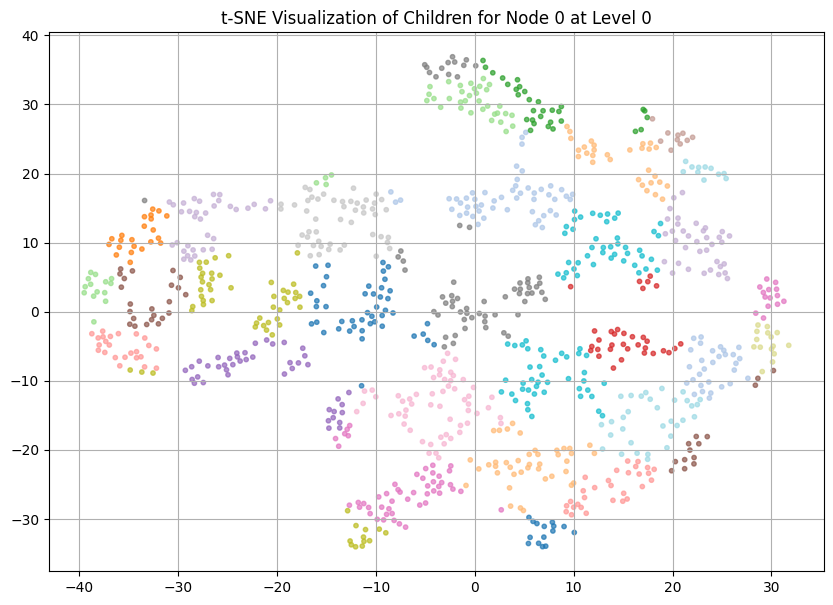

-------------------
Visualizing Level 0
-------------------
Generating t-SNE visualizations for children of nodes at Level 0...


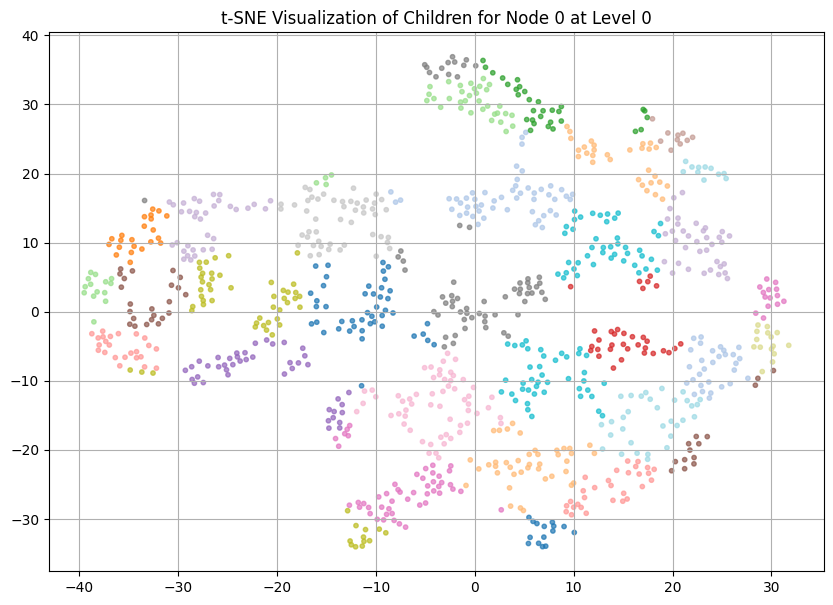

-------------------
Visualizing Level 1
-------------------
Generating t-SNE visualizations for children of nodes at Level 1...


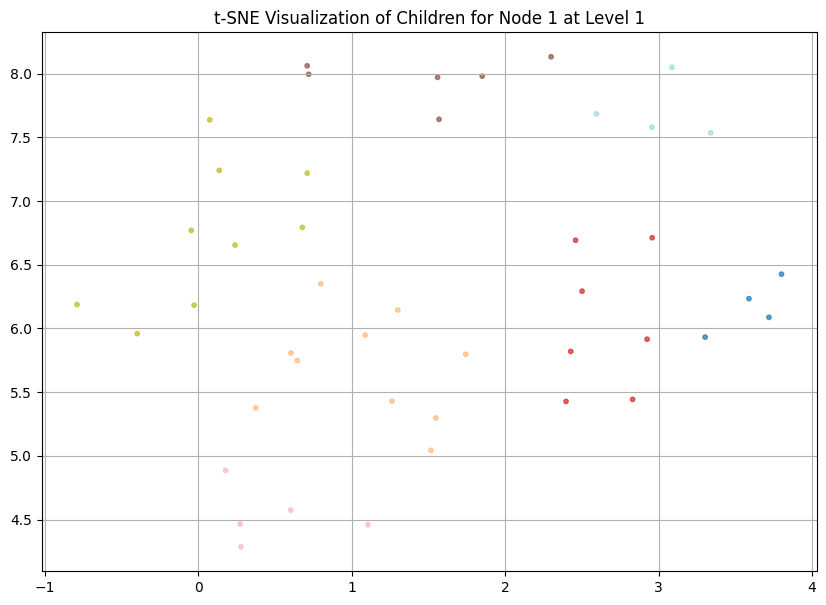

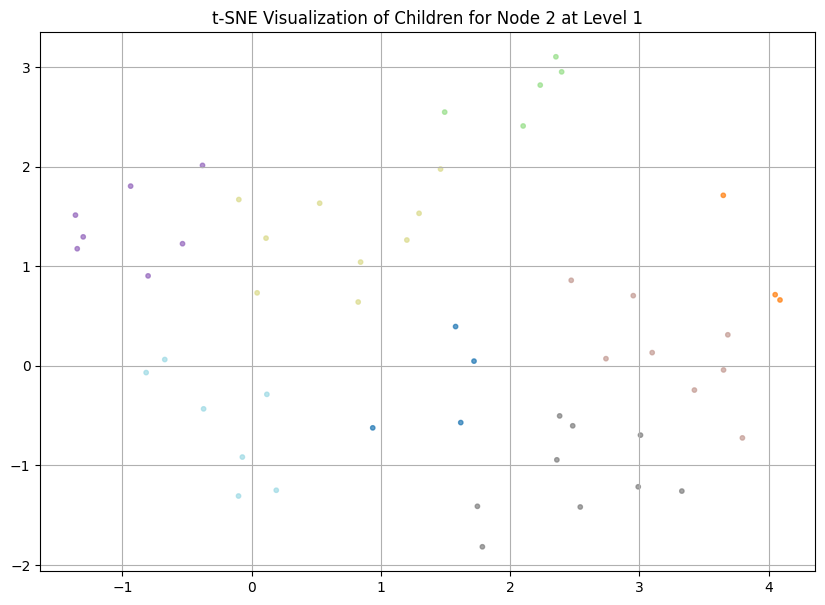

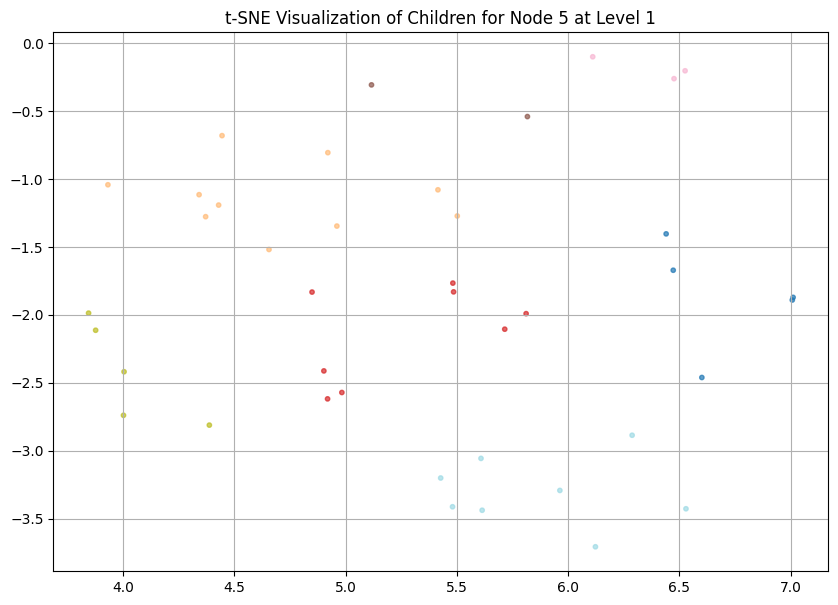

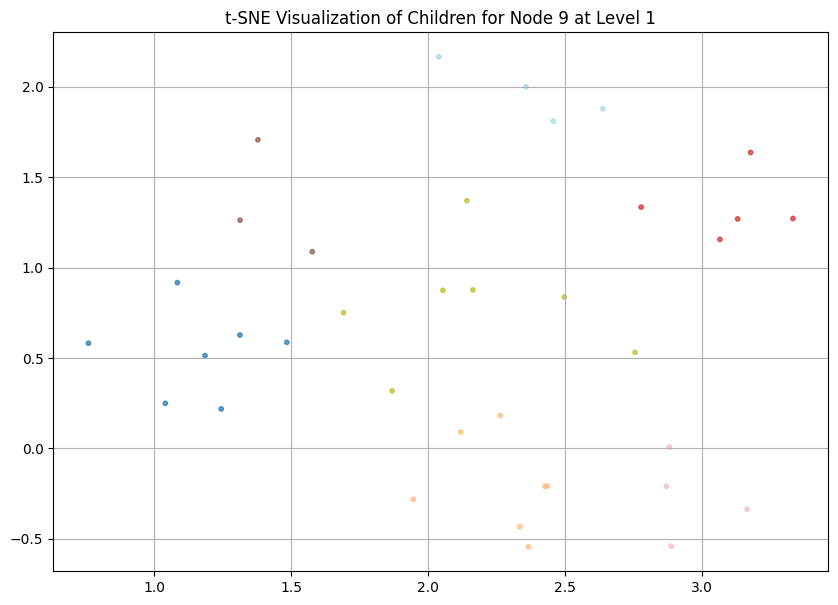

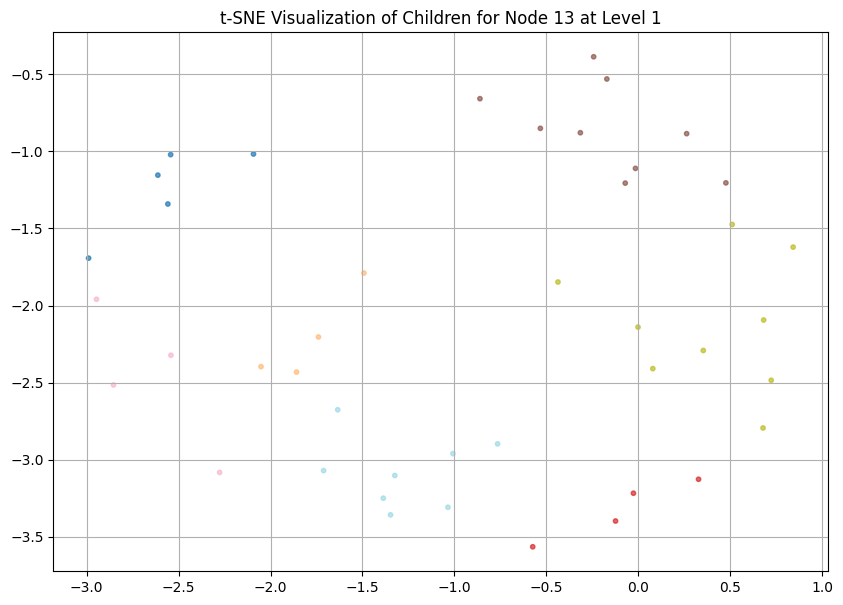

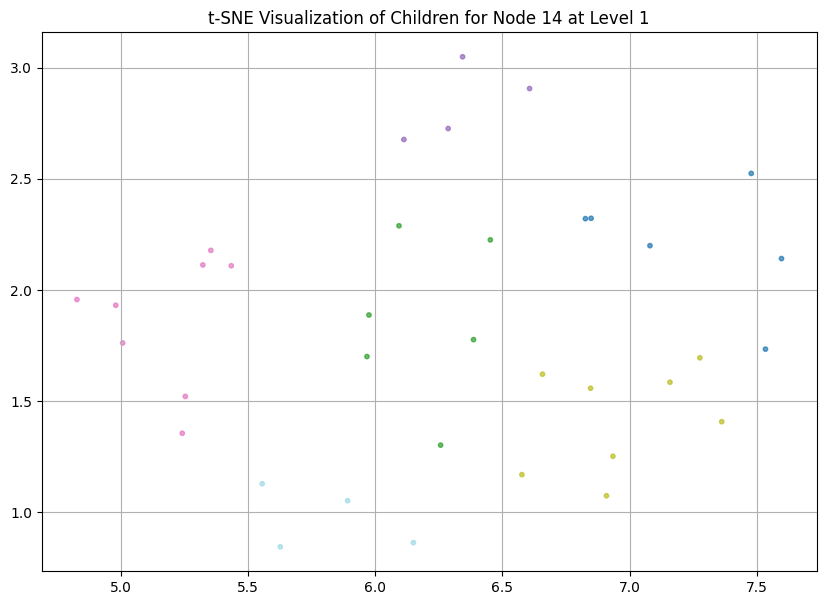

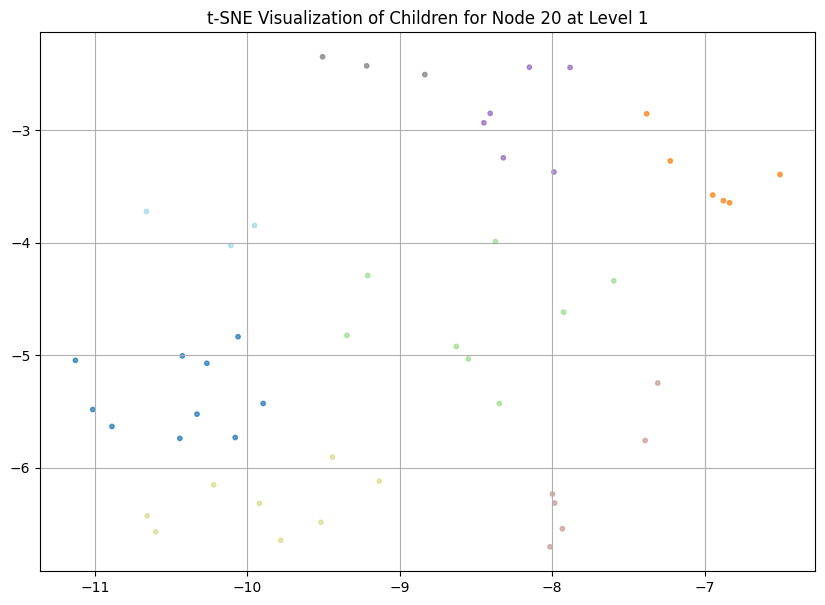

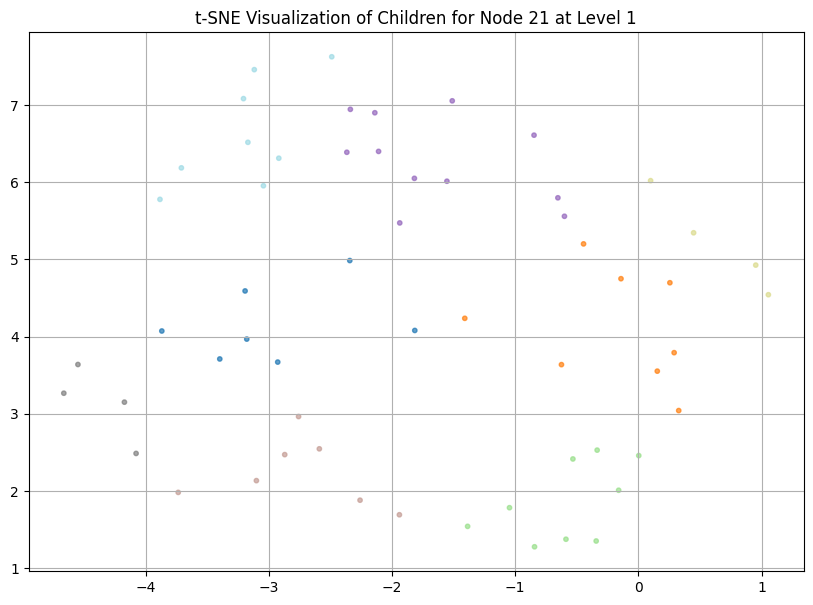

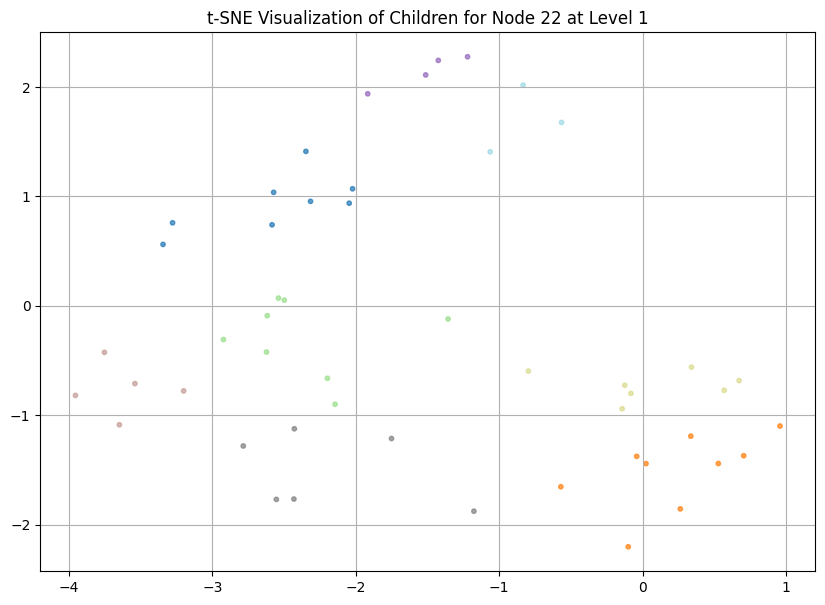

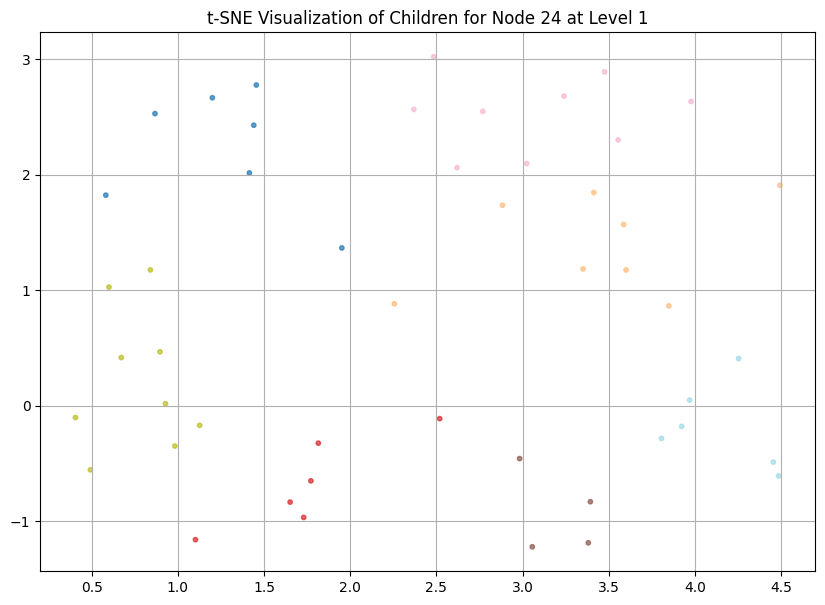

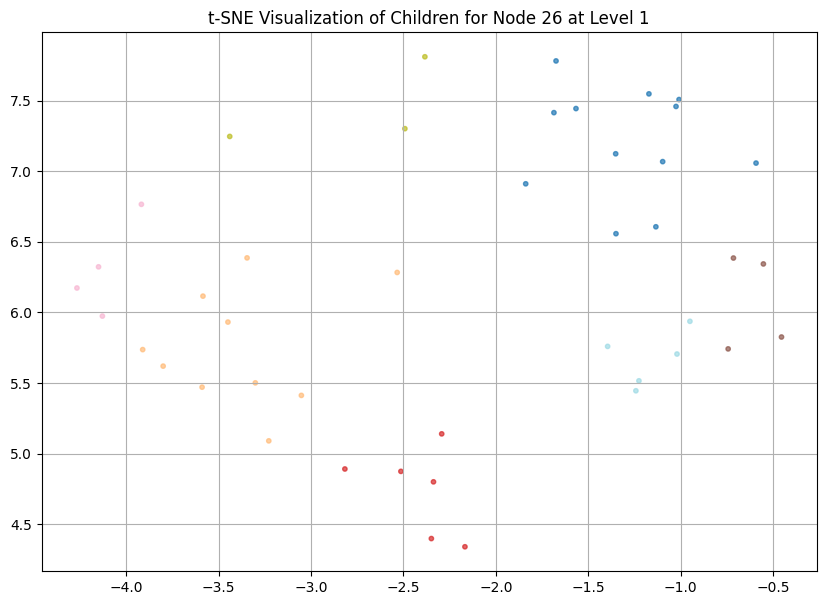

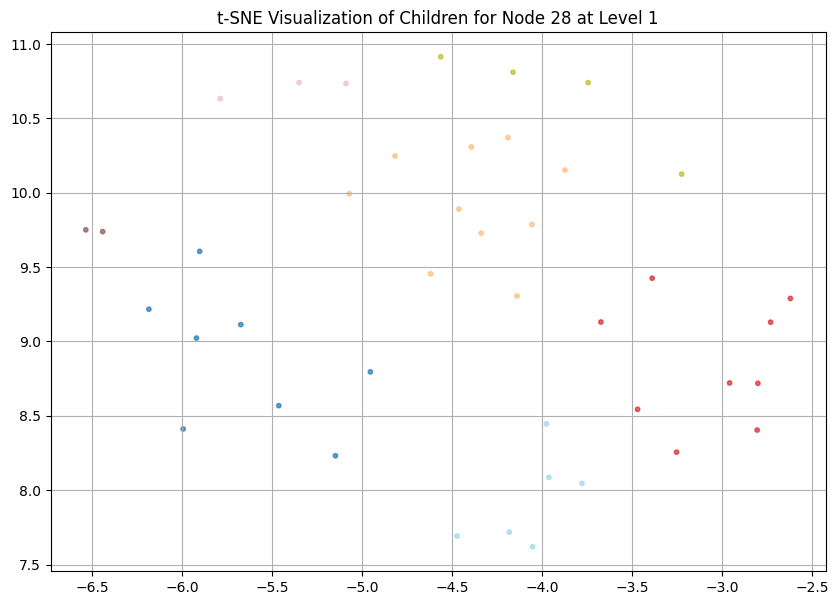

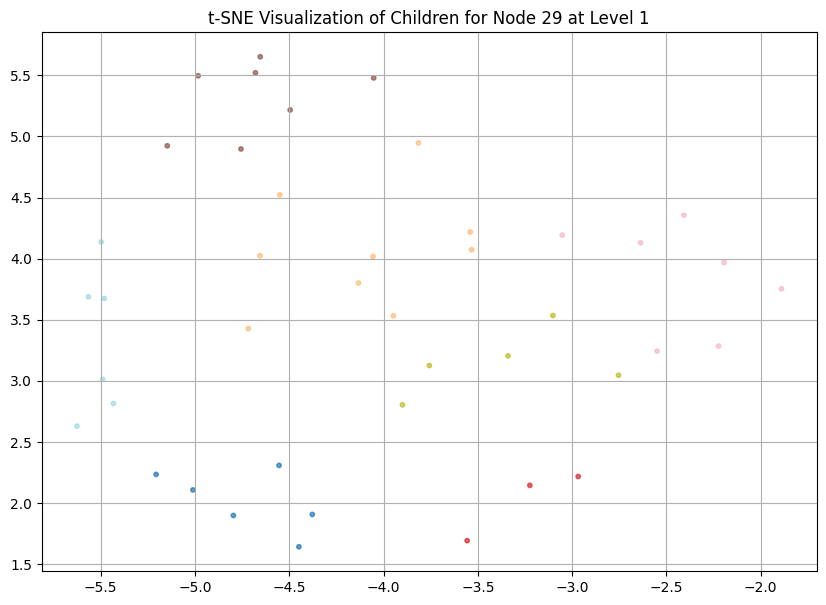

In [ ]:
def run_test():
    # Global Variables
    level = 0       # Visualization level
    top_k = 5       # Top K
    beam_width = 4  # Beam search

    # Create mock data
    print("-----------------")
    print("Initializing Data")
    print("-----------------")
    data = np.random.randn(1000, 2).astype(np.float32)

    # Build Index with custom fixed branching factor
    # This addresses your request for custom branch counts
    print("--------------")
    print("Building Index")
    print("--------------")
    tree = CentroidTreeSearch(
        data,
        levels=2,
        branching_mode="balanced",
        fixed_k=4
    )
    # tree = CentroidTreeSearch(
    #     bert_full_text,
    #     levels=2,
    #     branching_mode="balanced",
    #     fixed_k=8,
    #     metric="cosine",
    #     initial_labels=df_posts['bert_cluster']
    # )

    # Print Tree Stats
    print("----------")
    print("Tree Stats")
    print("----------")
    tree.print_tree_structure()

    # Test Search
    print("--------------")
    print("Testing Search")
    print("--------------")
    query = np.random.randn(2).astype(np.float32)
    values, indices, scores = tree.search(query, top_k=top_k, beam_width=beam_width)
    print(f"Top Values:")
    for i in range(top_k):
        print(values[i])
    print(f"Top Indices: {indices}")
    print(f"Top Scores:  {scores}")
    print()

    # Visualize specific level
    print(f"-------------------")
    print(f"Visualizing Level {level}")
    print(f"-------------------")
    tree.visualize_at_level(target_level=level)


    # Visualize specific level
    print(f"-------------------")
    print(f"Visualizing Level 0")
    print(f"-------------------")
    tree.visualize_at_level(target_level=0)

    # Visualize specific level
    print(f"-------------------")
    print(f"Visualizing Level 1")
    print(f"-------------------")
    tree.visualize_at_level(target_level=1)


if __name__ == "__main__":
    run_test()

## Search Engine

In [6]:
class SearchEngine:
    """
    A unified search engine class supporting multiple retrieval strategies:
    - Inverted Index (Exact/Aggregated keyword matching)
    - TF-IDF (Vector Space Model)
    - BM25 (Probabilistic Information Retrieval)
    - BERT (Dense Semantic Embedding)
    """

    def __init__(self, df=None, config: Dict[str, int] = {}, **kwargs):
        self.df = df

        # Weights
        # -------
        self.title_weight = config.get('title_weight', 1.0)
        self.fulltext_weight = config.get('fulltext_weight', 1.0)

        self.recall_weight = config.get('recall_weight', 1.0)
        self.tfidf_weight = config.get('tfidf_weight', 1.5)
        self.bm25_weight = config.get('bm25_weight', 1.5)
        self.bert_weight = config.get('bert_weight', 3.0)

        # Model and Data
        # --------------
        self.inverted_index_title = kwargs.get('inverted_index_title')
        self.inverted_index_fulltext = kwargs.get('inverted_index_fulltext')

        self.tfidf_vectorizer = kwargs.get('tfidf_vectorizer')
        self.tfidf_title_matrix = kwargs.get('tfidf_title_matrix')
        self.tfidf_fulltext_matrix = kwargs.get('tfidf_fulltext_matrix')

        self.bm25_title_model = kwargs.get('bm25_title_model')
        self.bm25_fulltext_model = kwargs.get('bm25_fulltext_model')

        self.bert_model = kwargs.get('bert_model')
        self.bert_title_matrix = kwargs.get('bert_title_matrix')
        self.bert_fulltext_matrix = kwargs.get('bert_fulltext_matrix')

    def _validate_query(self, query: str) -> str:
        if not query or not isinstance(query, str) or not query.strip():
            return None

        return query.strip()

    def _minmax_normalize(self, results: list) -> list:
        if not results:
            return results

        scores = [r['score'] for r in results]
        min_s, max_s = min(scores), max(scores)

        # Prevent division by zero
        if max_s == min_s:
            for r in results:
                r['score'] = 1.0
            return results

        for r in results:
            r['score'] = (r['score'] - min_s) / (max_s - min_s)

        return results


    def apply_business_rule(self, results: list, current_time: int = None) -> list:
        if self.df is None:
            raise ValueError("DataFrame is not initialized.")

        import time
        if current_time is None:
            current_time = int(time.time())

        processed_results = []

        for result in results:
            idx = result['id']
            post = self.df.loc[idx]

            # 1. Content Filtering: Remove deleted or removed posts
            content_str = str(post.get('content', '')).lower()
            if '[removed]' in content_str or '[deleted]' in content_str:
                continue

            # 2. Base Score
            score = result['score']

            # 3. Recency Boost (using the preprocessed timestamp)
            # We use 'created_utc_ts' which we generated in __init__
            post_time = post.get('created_utc_ts', current_time)
            seconds_old = max(0, current_time - post_time)
            days_old = seconds_old / (24 * 3600)
            time_decay = 1 / (1 + (days_old ** 0.5))

            # 4. Engagement Boost (Upvotes & Comments)
            # We use log1p (log(1+x)) to prevent massive viral posts from breaking the scale.
            engagement_boost = (
                np.log1p(post['score']) * 0.1 +
                np.log1p(post['num_comments']) * 0.05 +
                (post['upvote_ratio'] if 'upvote_ratio' in post else 0.5)
            )

            # 5. Language/Style Features
            # Boost for local flavor (Singlish) or expressive content (Emojis)
            style_boost = 1.0
            if post.get('has_emoji', False):
                style_boost += 0.1

            if post.get('singlish_count', 0) > 0:
                style_boost += 0.05 * min(post['singlish_count'], 5)

            # Calculate Final Score
            # ---------------------
            final_score = score * time_decay * engagement_boost * style_boost

            if final_score > 0:
                result['score'] = float(final_score)
                processed_results.append(result)

        # Re-sort results based on the new business-adjusted scores
        processed_results = sorted(processed_results, key=lambda x: x[1] if isinstance(x, tuple) else x['score'], reverse=True)

        return processed_results

    def inverted_index_recall(self, query: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None) -> list:
        clean_query = self._validate_query(query)
        if not clean_query:
            return []

        if self.inverted_index_title is None and self.inverted_index_fulltext is None:
            raise ValueError("Inverted index component is not initialized.")

        query_terms = clean_query.lower().split()
        doc_scores = {}

        for term in query_terms:
            # Fetch list of (doc_index, term_score)
            title_entries = self.inverted_index_title.get(term, [])
            fulltext_entries = self.inverted_index_fulltext.get(term, [])
            for title_index, score in title_entries:
                doc_scores[title_index] = doc_scores.get(title_index, 0) + self.title_weight

            for fulltext_index, score in fulltext_entries:
                doc_scores[fulltext_index] = doc_scores.get(fulltext_index, 0) + score * self.fulltext_weight

        if not doc_scores:
            return []

        # Sort by accumulated score in descending order
        sorted_results = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)

        results = []
        for idx, score in sorted_results:
            results.append({
                "id": int(idx),
                "score": float(score)
            })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]


        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]

        return results

    def tfidf_vector_search(self, query: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None, title_col: str = 'lemmatized_title', fulltext_col: str = 'lemmatized_fulltext') -> list:
        clean_query = self._validate_query(query)
        if not clean_query:
            return []

        if self.tfidf_vectorizer is None:
            raise ValueError("TF-IDF Vectorizer is not initialized.")

        # 1. Lazy initialization of matrices
        if self.tfidf_title_matrix is None:
            self.tfidf_title_matrix = self.tfidf_vectorizer.transform(self.df[title_col])

        if self.tfidf_fulltext_matrix is None:
            self.tfidf_fulltext_matrix = self.tfidf_vectorizer.transform(self.df[fulltext_col])

        # 2. Calculate Similarities
        query_vector = self.tfidf_vectorizer.transform([clean_query])

        # Title Similarity
        title_sims = cosine_similarity(query_vector, self.tfidf_title_matrix).flatten()
        # Fulltext Similarity
        fulltext_sims = cosine_similarity(query_vector, self.tfidf_fulltext_matrix).flatten()

        # 3. Apply Weights

        # Final combined score calculation
        combined_scores = (title_sims * self.title_weight) + (fulltext_sims * self.fulltext_weight)

        # 4. Rank and Build Results
        # Sort indices by combined score descending
        top_indices = combined_scores.argsort()[::-1]

        results = []
        for idx in top_indices:
            # We only keep items with some degree of similarity
            if combined_scores[idx] > 0:
                results.append({
                    "id": int(idx),
                    "score": float(combined_scores[idx])
                })

        # 5. Post-processing
        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)

        if top_n is not None:
            results = results[:top_n]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        if return_text:
            return [{
                'id': r['id'],
                'score': r['score'],
                'title': self.df.loc[r['id'], 'title'],
                'content': self.df.loc[r['id'], 'content']
                } for r in results]

        return results

    def bm25_search(self, query: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None) -> list:
        clean_query = self._validate_query(query)
        if not clean_query:
            return []

        # We check for at least one model
        if self.bm25_title_model is None and self.bm25_fulltext_model is None:
             raise ValueError("BM25 models are not initialized.")

        tokenized_query = clean_query.lower().split()

        # Initialize scores with zeros
        num_docs = len(self.df)
        combined_scores = np.zeros(num_docs)

        # Calculate Title Score
        if self.bm25_title_model is not None:
            title_scores = np.array(self.bm25_title_model.get_scores(tokenized_query))
            combined_scores += title_scores * self.title_weight

        # Calculate Fulltext Score
        if self.bm25_fulltext_model is not None:
            fulltext_scores = np.array(self.bm25_fulltext_model.get_scores(tokenized_query))
            combined_scores += fulltext_scores * self.fulltext_weight

        # Rank results
        top_indices = combined_scores.argsort()[::-1]

        results = []
        for idx in top_indices:
            if combined_scores[idx] > 0:
                results.append({
                    "id": int(idx),
                    "score": float(combined_scores[idx])
                })

        # Apply Business Rules
        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:top_n]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        # Return Text if requested
        if return_text:
            return [{
                'id': r['id'],
                'score': r['score'],
                'title': self.df.loc[r['id'], 'title'],
                'content': self.df.loc[r['id'], 'content']
                } for r in results]

        return results

    def bert_search(self, query: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None,
                    title_col: str = 'title', fulltext_col: str = 'content') -> list:
        clean_query = self._validate_query(query)
        if not clean_query:
            return []

        if self.bert_model is None:
            raise ValueError("BERT model is not initialized.")

        # 1. Lazy initialization of matrices (Title & Fulltext)
        if not hasattr(self, 'bert_title_matrix') or self.bert_title_matrix is None:
            print("Encoding BERT Title matrix...")
            self.bert_title_matrix = self.bert_model.encode(self.df[title_col].tolist(), show_progress_bar=True)

        if not hasattr(self, 'bert_fulltext_matrix') or self.bert_fulltext_matrix is None:
            print("Encoding BERT Fulltext matrix...")
            self.bert_fulltext_matrix = self.bert_model.encode(self.df[fulltext_col].tolist(), show_progress_bar=True)

        # 2. Calculate Embeddings and Similarities
        query_embedding = self.bert_model.encode([clean_query])

        title_sims = cosine_similarity(query_embedding, self.bert_title_matrix).flatten()
        fulltext_sims = cosine_similarity(query_embedding, self.bert_fulltext_matrix).flatten()

        # 3. Apply Weights
        combined_scores = (title_sims * self.title_weight) + (fulltext_sims * self.fulltext_weight)

        # 4. Rank Results
        top_indices = combined_scores.argsort()[::-1]

        results = []
        for idx in top_indices:
            # BERT similarities can be negative, but usually we filter by a threshold or keep positive
            results.append({
                "id": int(idx),
                "score": float(combined_scores[idx])
            })

        # Apply Business Rules
        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:top_n]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        # Return Text
        if return_text:
            return [{
                'id': r['id'],
                'score': r['score'],
                'title': self.df.loc[r['id'], 'title'],
                'content': self.df.loc[r['id'], 'content']
                } for r in results]

        return results

    def search(self, query: str, threshold: float = None, apply_rule: bool = None, return_text: bool = False, top_n: int = 10) -> list:
        clean_query = self._validate_query(query)
        if not clean_query:
            return []

        # Ensure at least one model is configured
        if not any([self.inverted_index_title, self.inverted_index_fulltext, self.tfidf_vectorizer, self.bm25_title_model, self.bm25_fulltext_model, self.bert_model]):
            raise RuntimeError("SearchEngine error: No models have been initialized.")

        # Master dictionary to accumulate weighted scores: {doc_index: total_score}
        master_scores = {}

        # 1. Aggregate Inverted Index Scores
        if self.inverted_index_title is not None or self.inverted_index_fulltext is not None:
            for item in self.inverted_index_recall(clean_query):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.recall_weight)

        # 2. Aggregate TF-IDF Scores
        if self.tfidf_vectorizer is not None:
            for item in self.tfidf_vector_search(clean_query):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.tfidf_weight)

        # 3. Aggregate BM25 Scores
        if self.bm25_title_model is not None or self.bm25_title_model is not None:
            for item in self.bm25_search(clean_query):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.bm25_weight)

        # 4. Aggregate BERT Semantic Scores
        if self.bert_model is not None:
            for item in self.bert_search(clean_query):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.bert_weight)

        if not master_scores:
            return []

        # Sort combined results by total score in descending order
        final_ranking = sorted(master_scores.items(), key=lambda x: x[1], reverse=True)

        results = []
        for idx, score in final_ranking:
            results.append({
                "id": int(idx),
                "score": float(score)
            })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]


        return results

### Unit Test

In [7]:
# Mocking a simple BM25-like behavior for testing
class MockBM25:
    def get_scores(self, query_tokens):
        return np.array([0.5, 1.2, 0.0])

class TestSearchEngine(unittest.TestCase):
    def setUp(self):
        # Sample data
        self.df = pd.DataFrame({
            'id': [101, 102, 103],
            'title': ['Singapore News', 'Transport Guide', 'Weather Report'],
            'full_text': ['Singapore is a city.', 'Public transport is great.', 'It is raining.'],
            'lemmatized_fulltext': ['singapore city', 'public transport great', 'rain'],
            'lemmatized_title': ['public', 'transport', 'singapore city'],
        })

        # Setup TF-IDF
        self.vectorizer = TfidfVectorizer()
        self.matrix = self.vectorizer.fit_transform(self.df['lemmatized_fulltext'])

        # Setup Inverted Index
        self.inv_title = {
            'singapore': [(0, 1.0)],
            'transport': [(1, 1.5)]
        }

        # Setup Inverted Index
        self.inv_fulltext = {
            'singapore': [(0, 1.0)],
            'transport': [(1, 1.5)]
        }

        self.engine = SearchEngine(
            df=self.df,
            inverted_index_title=self.inv_title,
            inverted_index_fulltext=self.inv_fulltext,
            tfidf_vectorizer=self.vectorizer,
            tfidf_fulltext_matrix=self.matrix,
            bm25_title_model=MockBM25(),
            bm25_fulltext_model=MockBM25()
        )

    def test_inverted_index(self):
        results = self.engine.inverted_index_recall("singapore")
        self.assertEqual(len(results), 1)
        self.assertEqual(results[0]['id'], 0) # Index of 'Singapore News'

    def test_tfidf_search(self):
        results = self.engine.tfidf_vector_search("transport", top_n=1)
        self.assertEqual(len(results), 1)
        self.assertGreater(results[0]['score'], 0)

    def test_empty_query(self):
        self.assertEqual(self.engine.bm25_search(""), [])
        self.assertEqual(self.engine.inverted_index_recall("   "), [])

    def test_invalid_initialization(self):
        empty_engine = SearchEngine(df=self.df)
        with self.assertRaises(ValueError):
            empty_engine.bert_search("test")

if __name__ == '__main__':
    unittest.main(argv=[''], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.051s

OK


### Example Usage

In [8]:
# ---------------------------
# Keyword Based Configuration
# ---------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.5,
#     "tfidf_weight": 2.0,
#     "bm25_weight": 2.5,
#     "bert_weight": 1.0
# }

# ----------------------------
# Semantic Based Configuration
# ----------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.0,
#     "tfidf_weight": 1.0,
#     "bm25_weight": 1.0,
#     "bert_weight": 2.5
# }

# --------------------
# Hybrid Configuration
# --------------------
weight_config: Dict[str, int] = {
    "recall_weight": 1.0,
    "title_weight": 2.0,
    "fulltext_weight": 1.0,

    "tfidf_weight": 2.0,
    "bm25_weight": 0.8,
    "bert_weight": 1.0
}

# 1. Prepare your Search Engine
# Assuming you have pre-trained/pre-computed components:
# tfidf_vectorizer, tfidf_matrix, bm25_model, bert_model, bert_matrix
search_engine = SearchEngine(
    df=df_posts,
    config=weight_config,
    inverted_index_title=inverted_index_titles,
    inverted_index_fulltext=inverted_index_full_text,
    tfidf_vectorizer=tfidf_posts_vectorizer,
    tfidf_title_matrix=tfidf_titles,
    tfidf_fulltext_matrix=tfidf_full_text,
    bm25_title_model=bm25_title_model,
    bm25_fulltext_model=bm25_fulltext_model,
    bert_model=bert_model,
    bert_title_matrix=bert_titles,
    bert_fulltext_matrix=bert_full_text
)

query = "How to use public transport in Singapore"

# 2. Execute Different Search Methods
print("-" * 110)
print(f"Results for Query: '{query}'")
print("-" * 110)
print()

# Inverted Index Recall (Keyword-based)
recall_results = search_engine.inverted_index_recall(query, threshold=0.3, top_n=5, apply_rule=True)
print("---------------------")
print("Inverted Index Recall")
print("---------------------")
print(f"Found {len(recall_results)} documents.")
print()
for i, result in enumerate(recall_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

print()

# TF-IDF
tfidf_results = search_engine.tfidf_vector_search(query, threshold=0.3, top_n=5, apply_rule=True)
print("-------------")
print("TF-IDF Search")
print("-------------")
print(f"Found {len(tfidf_results)} documents.")
print()
for i, result in enumerate(tfidf_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# BM25
bm25_results = search_engine.bm25_search(query, threshold=0.3, top_n=5, apply_rule=True)
print("-----------")
print("BM25 Search")
print("-----------")
print(f"Found {len(bm25_results)} documents.")
print()
for i, result in enumerate(bm25_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# BERT (Semantic-based)
bert_results = search_engine.bert_search(query, threshold=0.3, top_n=5, apply_rule=True)
print("-----------")
print("Bert Search")
print("-----------")
print(f"Found {len(bert_results)} documents.")
print()

for i, result in enumerate(bert_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# Hybrid Search
hybrid_results = search_engine.search(query, threshold=0.3, top_n=5, apply_rule=True)

print("-------------")
print("Hybrid Search")
print("-------------")
print(f"Found {len(hybrid_results)} documents.")
print()
for i, result in enumerate(hybrid_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

--------------------------------------------------------------------------------------------------------------
Results for Query: 'How to use public transport in Singapore'
--------------------------------------------------------------------------------------------------------------

---------------------
Inverted Index Recall
---------------------
Found 5 documents.

[1] ID: 29532 | Total Score: 1.0000
Title   : A call for transparency: Why Singapore's public transport needs a real-time information overhaul
Content : **Disclaimer:**   I know people are tired of complaints about the MRT breakdowns/delay/whatever you want to call it, but as negative sounding as this post is, please understand that it comes from a place of legitimate frustration and, most importantly, **constructive criticism**.  This is also not a...
--------------------------------------------------
[2] ID: 23816 | Total Score: 0.9466
Title   : As bars stay open later, calls grow for late-night public transport options

## Recommendation System

In [9]:
class RecommendationSystem:
    """
    A unified search engine class supporting multiple retrieval strategies:
    - Inverted Index (Exact/Aggregated keyword matching)
    - TF-IDF (Vector Space Model)
    - BM25 (Probabilistic Information Retrieval)
    - BERT (Dense Semantic Embedding)
    """

    def __init__(self, df=None, config: Dict[str, int] = {}, **kwargs):
        self.df = df

        # Weights
        # -------
        self.recall_weight = config.get('recall_weight', 1.0)
        self.tfidf_weight = config.get('tfidf_weight', 1.5)
        self.bm25_weight = config.get('bm25_weight', 1.5)
        self.bert_weight = config.get('bert_weight', 3.0)

        # Model and Data
        # --------------
        self.inverted_index = kwargs.get('inverted_index')
        self.tfidf_matrix = kwargs.get('tfidf_matrix')
        self.tfidf_vectorizer = kwargs.get('tfidf_vectorizer')
        self.bm25_model = kwargs.get('bm25_model')
        self.bert_matrix = kwargs.get('bert_matrix')
        self.bert_model = kwargs.get('bert_model')

    def _validate_fulltext(self, fulltext: str) -> str:
        if not fulltext or not isinstance(fulltext, str) or not fulltext.strip():
            return None

        return fulltext.strip()

    def _minmax_normalize(self, results: list) -> list:
        if not results:
            return results

        scores = [r['score'] for r in results]
        min_s, max_s = min(scores), max(scores)

        # Prevent division by zero
        if max_s == min_s:
            for r in results:
                r['score'] = 1.0
            return results

        for r in results:
            r['score'] = (r['score'] - min_s) / (max_s - min_s)

        return results


    def apply_business_rule(self, results: list, current_time: int = None) -> list:
        if self.df is None:
            raise ValueError("DataFrame is not initialized.")

        import time
        if current_time is None:
            current_time = int(time.time())

        processed_results = []

        for result in results:
            idx = result['id']
            post = self.df.loc[idx]

            # 1. Content Filtering: Remove deleted or removed posts
            content_str = str(post.get('content', '')).lower()
            if '[removed]' in content_str or '[deleted]' in content_str:
                continue

            # 2. Base Score
            score = result['score']

            # 3. Recency Boost (using the preprocessed timestamp)
            # We use 'created_utc_ts' which we generated in __init__
            post_time = post.get('created_utc_ts', current_time)
            seconds_old = max(0, current_time - post_time)
            days_old = seconds_old / (24 * 3600)
            time_decay = 1 / (1 + (days_old ** 0.5))

            # 4. Engagement Boost (Upvotes & Comments)
            # We use log1p (log(1+x)) to prevent massive viral posts from breaking the scale.
            engagement_boost = (
                np.log1p(post['score']) * 0.1 +
                np.log1p(post['num_comments']) * 0.05 +
                (post['upvote_ratio'] if 'upvote_ratio' in post else 0.5)
            )

            # 5. Language/Style Features
            # Boost for local flavor (Singlish) or expressive content (Emojis)
            style_boost = 1.0
            if post.get('has_emoji', False):
                style_boost += 0.1

            if post.get('singlish_count', 0) > 0:
                style_boost += 0.05 * min(post['singlish_count'], 5)

            # Calculate Final Score
            # ---------------------
            final_score = score * time_decay * engagement_boost * style_boost

            if final_score > 0:
                result['score'] = float(final_score)
                processed_results.append(result)

        # Re-sort results based on the new business-adjusted scores
        processed_results = sorted(processed_results, key=lambda x: x[1] if isinstance(x, tuple) else x['score'], reverse=True)

        return processed_results

    def inverted_index_recall(self, fulltext: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None) -> list:
        clean_fulltext = self._validate_fulltext(fulltext)
        if not clean_fulltext:
            return []

        if self.inverted_index is None:
            raise ValueError("Inverted index component is not initialized.")

        fulltext_terms = clean_fulltext.lower().split()
        doc_scores = {}

        for term in fulltext_terms:
            # Fetch list of (doc_index, term_score)
            doc_entries = self.inverted_index.get(term, [])
            for doc_index, score in doc_entries:
                doc_scores[doc_index] = doc_scores.get(doc_index, 0) + score

        if not doc_scores:
            return []

        # Sort by accumulated score in descending order
        sorted_results = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)

        results = []
        for idx, score in sorted_results:
            results.append({
                "id": int(idx),
                "score": float(score)
            })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]

        return results

    def tfidf_vector_search(self, fulltext: str, threshold: float = None, apply_rule: bool = False, return_text: bool = False, top_n: int = None, text_col: str = 'lemmatized_fulltext') -> list:
        clean_fulltext = self._validate_fulltext(fulltext)
        if not clean_fulltext:
            return []

        if self.tfidf_vectorizer is None:
            raise ValueError("TF-IDF Vectorizer is not initialized.")

        # Lazy initialization of the TF-IDF matrix if not provided
        if self.tfidf_matrix is None:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            self.tfidf_matrix = self.tfidf_vectorizer.transform(self.df[text_col])

        fulltext_vector = self.tfidf_vectorizer.transform([clean_fulltext])
        similarities = cosine_similarity(fulltext_vector, self.tfidf_matrix).flatten()

        # Sort indices by similarity descending
        top_indices = similarities.argsort()[::-1]

        results = []
        for idx in top_indices:
            if idx < len(self.df):
                results.append({
                    "id": int(idx),
                    "score": float(similarities[idx])
                })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]

        return results

    def bm25_search(self, fulltext: str, threshold: float = None, apply_rule: bool = None, return_text: bool = False, top_n: int = None) -> list:
        clean_fulltext = self._validate_fulltext(fulltext)
        if not clean_fulltext:
            return []

        if self.bm25_model is None:
            raise ValueError("BM25 model is not initialized.")

        # Standard BM25 implementations require tokenized input
        tokenized_fulltext = clean_fulltext.lower().split()
        scores = self.bm25_model.get_scores(tokenized_fulltext)

        top_indices = np.argsort(scores)[::-1]

        results = []
        for idx in top_indices:
            if idx < len(self.df):
                results.append({
                    "id": int(idx),
                    "score": float(scores[idx])
                })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]


        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]


        # Only return results with a positive correlation score
        return results

    def bert_search(self, fulltext: str, threshold: float = None, apply_rule: bool = None, return_text: bool = False,  top_n: int = None, text_col: str = 'full_text') -> list:
        clean_fulltext = self._validate_fulltext(fulltext)
        if not clean_fulltext:
            return []

        if self.bert_model is None:
            raise ValueError("BERT model (SentenceTransformer) is not initialized.")

        if self.bert_matrix is None:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            print("Encoding BERT matrix... this may be slow for large datasets.")
            self.bert_matrix = self.bert_model.encode(self.df[text_col].tolist())

        fulltext_embedding = self.bert_model.encode([clean_fulltext])
        sims = cosine_similarity(fulltext_embedding, self.bert_matrix).flatten()

        top_indices = sims.argsort()[::-1]

        results = []
        for idx in top_indices:
            if idx < len(self.df):
                results.append({
                    "id": int(idx),
                    "score": float(sims[idx])
                })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]

        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]

        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]

        return results

    def search(self, fulltext: str, threshold: float = None, apply_rule: bool = None, return_text: bool = False, top_n: int = 10) -> list:
        clean_fulltext = self._validate_fulltext(fulltext)
        if not clean_fulltext:
            return []

        # Ensure at least one model is configured
        if not any([self.inverted_index, self.tfidf_vectorizer, self.bm25_model, self.bert_model]):
            raise RuntimeError("SearchEngine error: No models have been initialized.")

        # Master dictionary to accumulate weighted scores: {doc_index: total_score}
        master_scores = {}

        # 1. Aggregate Inverted Index Scores
        if self.inverted_index is not None:
            for item in self.inverted_index_recall(clean_fulltext):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.recall_weight)

        # 2. Aggregate TF-IDF Scores
        if self.tfidf_vectorizer is not None:
            for item in self.tfidf_vector_search(clean_fulltext):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.tfidf_weight)

        # 3. Aggregate BM25 Scores
        if self.bm25_model is not None:
            for item in self.bm25_search(clean_fulltext):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.bm25_weight)

        # 4. Aggregate BERT Semantic Scores
        if self.bert_model is not None:
            for item in self.bert_search(clean_fulltext):
                master_scores[item['id']] = master_scores.get(item['id'], 0) + (item['score'] * self.bert_weight)

        if not master_scores:
            return []

        # Sort combined results by total score in descending order
        final_ranking = sorted(master_scores.items(), key=lambda x: x[1], reverse=True)

        results = []
        for idx, score in final_ranking:
            results.append({
                "id": int(idx),
                "score": float(score)
            })

        if apply_rule:
            results = self.apply_business_rule(results)

        results = self._minmax_normalize(results)
        if top_n is not None:
            results = results[:min(len(results), top_n)]


        if threshold is not None:
            results = [result for result in results if result['score'] >= threshold]


        if return_text:
            if self.df is None:
                raise ValueError("DataFrame is not initialized.")

            original_df = self.df
            return [{
                'id': result['id'],
                'score': result['score'],
                'title': original_df.loc[result['id'], 'title'],
                'content': original_df.loc[result['id'], 'content']
                } for result in results]


        return results

### Unit Test

In [10]:
# Mocking a simple BM25-like behavior for testing
class MockBM25:
    def get_scores(self, fulltext_tokens):
        return np.array([0.5, 1.2, 0.0])

class TestSearchEngine(unittest.TestCase):
    def setUp(self):
        # Sample data
        self.df = pd.DataFrame({
            'id': [101, 102, 103],
            'title': ['Singapore News', 'Transport Guide', 'Weather Report'],
            'full_text': ['Singapore is a city.', 'Public transport is great.', 'It is raining.'],
            'lemmatized_fulltext': ['singapore city', 'public transport great', 'rain']
        })

        # Setup TF-IDF
        self.vectorizer = TfidfVectorizer()
        self.matrix = self.vectorizer.fit_transform(self.df['lemmatized_fulltext'])

        # Setup Inverted Index
        self.inv_index = {
            'singapore': [(0, 1.0)],
            'transport': [(1, 1.5)]
        }

        self.engine = RecommendationSystem(
            df=self.df,
            inverted_index=self.inv_index,
            tfidf_vectorizer=self.vectorizer,
            tfidf_matrix=self.matrix,
            bm25_model=MockBM25()
        )

    def test_inverted_index(self):
        results = self.engine.inverted_index_recall("singapore")
        self.assertEqual(len(results), 1)
        self.assertEqual(results[0]['id'], 0) # Index of 'Singapore News'

    def test_tfidf_search(self):
        results = self.engine.tfidf_vector_search("transport", top_n=1)
        self.assertEqual(len(results), 1)
        self.assertGreater(results[0]['score'], 0)

    def test_empty_fulltext(self):
        self.assertEqual(self.engine.bm25_search(""), [])
        self.assertEqual(self.engine.inverted_index_recall("   "), [])

    def test_invalid_initialization(self):
        empty_engine = SearchEngine(df=self.df)
        with self.assertRaises(ValueError):
            empty_engine.bert_search("test")

if __name__ == '__main__':
    unittest.main(argv=[''], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.019s

OK


### Example Usage

In [11]:
# ---------------------------
# Keyword Based Configuration
# ---------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.5,
#     "tfidf_weight": 2.0,
#     "bm25_weight": 2.5,
#     "bert_weight": 1.0
# }

# ----------------------------
# Semantic Based Configuration
# ----------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.0,
#     "tfidf_weight": 1.0,
#     "bm25_weight": 1.0,
#     "bert_weight": 2.5
# }

# --------------------
# Hybrid Configuration
# --------------------
weight_config: Dict[str, int] = {
    "recall_weight": 1.2,
    "tfidf_weight": 1.3,
    "bm25_weight": 1.8,
    "bert_weight": 1.5
}
# 1. Prepare your Search Engine
# Assuming you have pre-trained/pre-computed components:
# tfidf_vectorizer, tfidf_matrix, bm25_model, bert_model, bert_matrix
recsys = RecommendationSystem(
    df=df_posts,
    config=weight_config,
    inverted_index=inverted_index_full_text,
    tfidf_vectorizer=tfidf_posts_vectorizer,
    tfidf_matrix=tfidf_full_text,
    bm25_model=bm25_fulltext_model,
    bert_model=bert_model,
    bert_matrix=bert_full_text
)


idx: int = 4000
# Very Good: 2000, 4000, 5000, 8000, 20000, 30000
# Nice: 31812, 15000
# Bad: 7000, 9000, 10000
post = df_posts.loc[idx]
title: str = post['title']
content: str = post['content']
fulltext: str = post['lemmatized_full_text']

# 2. Execute Different Search Methods
print("-" * 110)
print(f"Results for article index {idx}:")
print(f"Title: {title}")
print(f"Content: {content[:300]}")
print("-" * 110)
print()

# Inverted Index Recall (Keyword-based)
recall_results = recsys.inverted_index_recall(fulltext, threshold=0.3, top_n=5, apply_rule=True)
print("---------------------")
print("Inverted Index Recall")
print("---------------------")
print(f"Found {len(recall_results)} documents.")
print()
for i, result in enumerate(recall_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

print()

# TF-IDF
tfidf_results = recsys.tfidf_vector_search(fulltext, threshold=0.3, top_n=5, apply_rule=True)
print("-------------")
print("TF-IDF Search")
print("-------------")
print(f"Found {len(tfidf_results)} documents.")
print()
for i, result in enumerate(tfidf_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# BM25
bm25_results = recsys.bm25_search(fulltext, threshold=0.3, top_n=5, apply_rule=True)
print("-----------")
print("BM25 Search")
print("-----------")
print(f"Found {len(bm25_results)} documents.")
print()
for i, result in enumerate(bm25_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# BERT (Semantic-based)
bert_results = recsys.bert_search(fulltext, threshold=0.3, top_n=5, apply_rule=True)
print("-----------")
print("Bert Search")
print("-----------")
print(f"Found {len(bert_results)} documents.")
print()

for i, result in enumerate(bert_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

# Hybrid Search
hybrid_results = recsys.search(fulltext, threshold=0.3, top_n=5, apply_rule=True)

print("-------------")
print("Hybrid Search")
print("-------------")
print(f"Found {len(hybrid_results)} documents.")
print()
for i, result in enumerate(hybrid_results):
    post = df_posts.loc[result['id']]

    print(f"[{i + 1}] ID: {result['id']} | Total Score: {result['score']:.4f}")
    print(f"Title   : {post['title']}")

    content_snippet = str(post['content']).replace('\n', ' ')
    print(f"Content : {content_snippet[:300]}...")

    print("-" * 50)

--------------------------------------------------------------------------------------------------------------
Results for article index 4000:
Title: Fire at kranji warehouse
Content: Thick smoke seen 

Hope everything is alright 

SCDF is fighting the fires bravely.
--------------------------------------------------------------------------------------------------------------

---------------------
Inverted Index Recall
---------------------
Found 5 documents.

[1] ID: 25277 | Total Score: 1.0000
Title   : anyone else seen this?
Content : QR code leads to: https://www.solveforx.sg/  seems like something government related based on the go gov QR code. not sure what it could be but I'm too lazy to go and actually solve it. anyone wants to be a sleuth?...
--------------------------------------------------
[2] ID: 4152 | Total Score: 0.9674
Title   : Kranji Crescent fire put out after 4 days: SCDF
Content : ...
--------------------------------------------------
[3] ID: 31674 | Total Score:

## Evaluation

### Load Data

In [13]:
df_test1 = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/test1.csv', keep_default_na=False)
df_test2 = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/test2.csv', keep_default_na=False)

In [14]:
print("---------")
print("Test Data")
print("---------")
display(df_test1.head(5))
print()

n: int = 5

for i in range(n):
    post = df_test1.loc[i]
    original_id = post['original_index']
    print("-" * 300)
    print("Title:", df_posts.loc[original_id]['title'])
    print("Content:", df_posts.loc[original_id]['content'])
    print("-" * 300)
    for i in range(5):
        id: int = post[f'recommended_index_{i + 1}']
        if not isinstance(id, np.int64):
            continue

        print(f"Recommended Post {i + 1}:")
        print(f"Title: {df_posts.loc[id]['title']}")
        print(f"Content: {df_posts.loc[id]['content']}")
        print()

    print()

---------
Test Data
---------


,original_index,recommended_index_1,recommended_index_2,recommended_index_3,recommended_index_4,recommended_index_5
0,5949,11616,576,14834,21112,4609
1,6877,7151,7032,6751,6518,7282
2,7555,7550,4466,11375,7195,21775
3,7688,10140,8206,8069,7499,9110
4,9628,8564,8196,8060,8457,88



------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Title: HDB resale price : Stackhomes
Content: Singapore's resale flat prices only look crazy because of rare maisonettes, jumbo flats, etc. right? NOT QUITE. Here's why:
What you're seeing is the rise in resale flat prices.
ALL of them have been going up since COVID
(Thanks, 2020.)
This ALL the flats together: regular flats, as well as special.
So if "special flats" make prices high, then the price spike is lower if we remove them right?
Watch what happens next:

IT'S WORSE. When we exclude maisonettes, jumbo flats, etc., the over rise in resale flat prices is EVEN HIGHER.
As it turns out, those maisonettes and jumbo flats were dragging resale flat prices down.


Source: stackedhomes 
----

### Initialization

In [15]:
# ---------------------------
# Keyword Based Configuration
# ---------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.5,
#     "tfidf_weight": 2.0,
#     "bm25_weight": 2.5,
#     "bert_weight": 1.0
# }

# ----------------------------
# Semantic Based Configuration
# ----------------------------
# weight_config: Dict[str, int] = {
#     "recall_weight": 1.0,
#     "tfidf_weight": 1.0,
#     "bm25_weight": 1.0,
#     "bert_weight": 2.5
# }

# --------------------
# Hybrid Configuration
# --------------------
weight_config: Dict[str, int] = {
    "recall_weight": 1.2,
    "tfidf_weight": 1.3,
    "bm25_weight": 1.8,
    "bert_weight": 1.5
}

# 1. Prepare your Search Engine
# Assuming you have pre-trained/pre-computed components:
# tfidf_vectorizer, tfidf_matrix, bm25_model, bert_model, bert_matrix
recsys = RecommendationSystem(
    df=df_posts,
    config=weight_config,
    inverted_index=inverted_index_full_text,
    tfidf_vectorizer=tfidf_posts_vectorizer,
    tfidf_matrix=tfidf_full_text,
    bm25_model=bm25_fulltext_model,
    bert_model=bert_model,
    bert_matrix=bert_full_text
)

In [16]:
import numpy as np

def dcg(relevance):
    return sum(rel / np.log2(idx + 2) for idx, rel in enumerate(relevance))

def ndcg_at_k(answers, groundtruths, k=6):
    # Calculate the relevance of the actual retrieved results (1 if hit, 0 otherwise)
    relevance = [1 if ans in groundtruths else 0 for ans in answers[:k]]

    # Calculate DCG for the actual retrieved results
    dcg_score = dcg(relevance)

    # Calculate the 'ideal' relevance.
    # In an ideal scenario, all groundtruths would be ranked at the top, up to k.
    num_hits_possible = min(len(groundtruths), k)
    ideal_relevance = [1] * num_hits_possible + [0] * (k - num_hits_possible)

    # Calculate Ideal DCG (IDCG)
    idcg_score = dcg(ideal_relevance)

    # Return NDCG (DCG / IDCG). If IDCG is 0 (no relevant items or k=0), return 0 to avoid division by zero.
    return dcg_score / idcg_score if idcg_score > 0 else 0


### Inverted Index

#### Evaluation 1

In [ ]:
thresholds = [i / 10 for i in range(11)]
# thresholds = np.linspace(0, 1, 10) # Alternative for more granular thresholds

best_ndcg_1 = -1
best_ndcg_threshold_1 = None

best_mrr_1 = -1
best_mrr_threshold_1 = None

best_f1_1 = -1
best_f1_threshold_1 = None
best_metrics_1 = None

pr_points_1 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    num_test = len(df_test1) # Number of test cases in df_test1
    # num_test = 2 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test1.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform inverted index search using the current threshold
        hybrid_results = recsys.inverted_index_recall(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_1.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_1:
        best_ndcg_1 = avg_ndcg
        best_ndcg_threshold_1 = threshold

    if avg_mrr > best_mrr_1:
        best_mrr_1 = avg_mrr
        best_mrr_threshold_1 = threshold

    if f1 > best_f1_1:
        best_f1_1 = f1
        best_f1_threshold_1 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_1:.4f} (threshold={best_ndcg_threshold_1})")
print(f"Best MRR: {best_mrr_1:.4f} (threshold={best_mrr_threshold_1})")
print(f"Best F1: {best_f1_1:.4f} (threshold={best_f1_threshold_1})")


Processing Threshold 0.0: 100%|██████████| 31/31 [00:28<00:00,  1.08it/s]


Threshold: 0.0
NDCG@6: 0.4860
Precision: 0.4839
Recall: 0.4839
F1: 0.4839
MRR: 0.6532



Processing Threshold 0.1: 100%|██████████| 31/31 [00:30<00:00,  1.02it/s]


Threshold: 0.1
NDCG@6: 0.4860
Precision: 0.4839
Recall: 0.4839
F1: 0.4839
MRR: 0.6532



Processing Threshold 0.2: 100%|██████████| 31/31 [00:28<00:00,  1.09it/s]


...

Threshold: 0.8
NDCG@6: 0.3325
Precision: 0.5500
Recall: 0.2903
F1: 0.3800
MRR: 0.6210



Processing Threshold 0.9: 100%|██████████| 31/31 [00:29<00:00,  1.06it/s]


Threshold: 0.9
NDCG@6: 0.2512
Precision: 0.4812
Recall: 0.1935
F1: 0.2761
MRR: 0.5323



Processing Threshold 1.0: 100%|██████████| 31/31 [00:29<00:00,  1.07it/s]

Threshold: 1.0
NDCG@6: 0.1464
Precision: 0.4839
Recall: 0.0806
F1: 0.1382
MRR: 0.4839

------------
Best Results
------------
Best NDCG@6: 0.4860 (threshold=0.0)
Best MRR: 0.6532 (threshold=0.0)
Best F1: 0.4887 (threshold=0.5)


##### PR Curve

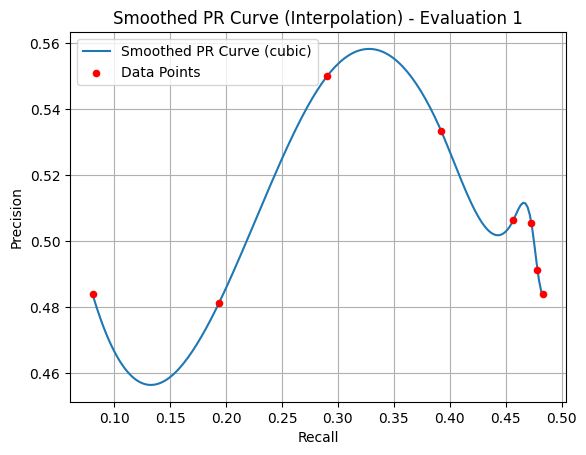

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_1:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 1")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 1")
    plt.grid(True)
    plt.legend()
    plt.show()


In this work, ROC AUC is not an appropriate evaluation metric because the task is formulated as a ranking-based recommendation problem rather than a binary classification problem. First, the dataset is highly imbalanced, where each query has only a small number of relevant (positive) items among a very large pool of non-relevant (negative) items. This causes ROC AUC to be overly optimistic, as the large number of true negatives can dominate the evaluation and obscure the model’s actual ability to identify relevant items. Second, ROC AUC evaluates the model’s overall ranking performance across all items, but it does not emphasize the quality of the top-ranked results, which are the most important in recommendation scenarios. Third, ROC AUC requires a complete scoring over all candidate items, whereas our system is based on a threshold-based retrieval approach that only returns a subset of results. Therefore, ROC AUC does not align well with our system design or evaluation goals. Instead, metrics such as NDCG@K, Precision@K, Recall@K, and MRR are more suitable, as they better capture the effectiveness of ranking and the quality of top recommendations.

#### Evaluation 2

In [ ]:
# thresholds = [i / 10 for i in range(11)]
thresholds = np.linspace(0, 1, 5) # Alternative for more granular thresholds

best_ndcg_2 = -1
best_ndcg_threshold_2 = None

best_mrr_2 = -1
best_mrr_threshold_2 = None

best_f1_2 = -1
best_f1_threshold_2 = None
best_metrics_2 = None

pr_points_2 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    # num_test = len(df_test2) # Number of test cases in df_test2
    num_test = 200 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test2.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.inverted_index_recall(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_2.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_2:
        best_ndcg_2 = avg_ndcg
        best_ndcg_threshold_2 = threshold

    if avg_mrr > best_mrr_2:
        best_mrr_2 = avg_mrr
        best_mrr_threshold_2 = threshold

    if f1 > best_f1_2:
        best_f1_2 = f1
        best_f1_threshold_2 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_2:.4f} (threshold={best_ndcg_threshold_2})")
print(f"Best MRR: {best_mrr_2:.4f} (threshold={best_mrr_threshold_2})")
print(f"Best F1: {best_f1_2:.4f} (threshold={best_f1_threshold_2})")


Processing Threshold 0.0: 100%|██████████| 200/200 [02:18<00:00,  1.44it/s]


Threshold: 0.0
NDCG@6: 0.5247
Precision: 0.2425
Recall: 0.4850
F1: 0.3233
MRR: 0.7959



Processing Threshold 0.25: 100%|██████████| 200/200 [02:13<00:00,  1.50it/s]


Threshold: 0.25
NDCG@6: 0.5247
Precision: 0.2433
Recall: 0.4850
F1: 0.3241
MRR: 0.7959



Processing Threshold 0.5: 100%|██████████| 200/200 [02:10<00:00,  1.53it/s]


Threshold: 0.5
NDCG@6: 0.4973
Precision: 0.4118
Recall: 0.4450
F1: 0.4277
MRR: 0.7959



Processing Threshold 0.75: 100%|██████████| 200/200 [02:10<00:00,  1.53it/s]


Threshold: 0.75
NDCG@6: 0.4261
Precision: 0.6750
Recall: 0.3467
F1: 0.4581
MRR: 0.7849



Processing Threshold 1.0: 100%|██████████| 200/200 [02:11<00:00,  1.52it/s]

Threshold: 1.0
NDCG@6: 0.3449
Precision: 0.7350
Recall: 0.2450
F1: 0.3675
MRR: 0.7350

------------
Best Results
------------
Best NDCG@6: 0.5247 (threshold=0.0)
Best MRR: 0.7959 (threshold=0.0)
Best F1: 0.4581 (threshold=0.75)


##### PR Curve

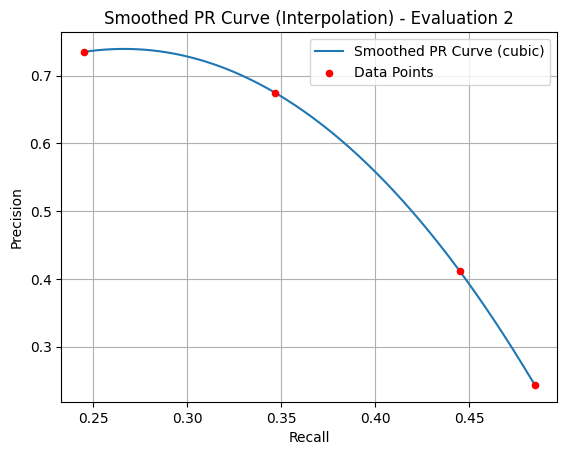

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_2:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 2")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 2")
    plt.grid(True)
    plt.legend()
    plt.show()


### TF-IDF

#### Evaluation 1

In [ ]:
thresholds = [i / 10 for i in range(11)]
# thresholds = np.linspace(0, 1, 10) # Alternative for more granular thresholds

best_ndcg_1 = -1
best_ndcg_threshold_1 = None

best_mrr_1 = -1
best_mrr_threshold_1 = None

best_f1_1 = -1
best_f1_threshold_1 = None
best_metrics_1 = None

pr_points_1 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    num_test = len(df_test1) # Number of test cases in df_test1
    # num_test = 2 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test1.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.tfidf_vector_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_1.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_1:
        best_ndcg_1 = avg_ndcg
        best_ndcg_threshold_1 = threshold

    if avg_mrr > best_mrr_1:
        best_mrr_1 = avg_mrr
        best_mrr_threshold_1 = threshold

    if f1 > best_f1_1:
        best_f1_1 = f1
        best_f1_threshold_1 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_1:.4f} (threshold={best_ndcg_threshold_1})")
print(f"Best MRR: {best_mrr_1:.4f} (threshold={best_mrr_threshold_1})")
print(f"Best F1: {best_f1_1:.4f} (threshold={best_f1_threshold_1})")


Processing Threshold 0.0: 100%|██████████| 31/31 [01:38<00:00,  3.17s/it]


Threshold: 0.0
NDCG@6: 0.7622
Precision: 0.7151
Recall: 0.7151
F1: 0.7151
MRR: 0.9742



Processing Threshold 0.1: 100%|██████████| 31/31 [01:36<00:00,  3.12s/it]


Threshold: 0.1
NDCG@6: 0.7622
Precision: 0.7151
Recall: 0.7151
F1: 0.7151
MRR: 0.9742



Processing Threshold 0.2: 100%|██████████| 31/31 [01:36<00:00,  3.13s/it]


...

Threshold: 0.8
NDCG@6: 0.4506
Precision: 0.9677
Recall: 0.3441
F1: 0.5077
MRR: 0.9677



Processing Threshold 0.9: 100%|██████████| 31/31 [01:35<00:00,  3.09s/it]


Threshold: 0.9
NDCG@6: 0.3815
Precision: 0.9677
Recall: 0.2527
F1: 0.4007
MRR: 0.9677



Processing Threshold 1.0: 100%|██████████| 31/31 [01:34<00:00,  3.04s/it]

Threshold: 1.0
NDCG@6: 0.2928
Precision: 0.9677
Recall: 0.1613
F1: 0.2765
MRR: 0.9677

------------
Best Results
------------
Best NDCG@6: 0.7622 (threshold=0.0)
Best MRR: 0.9742 (threshold=0.0)
Best F1: 0.7151 (threshold=0.0)


##### PR Curve

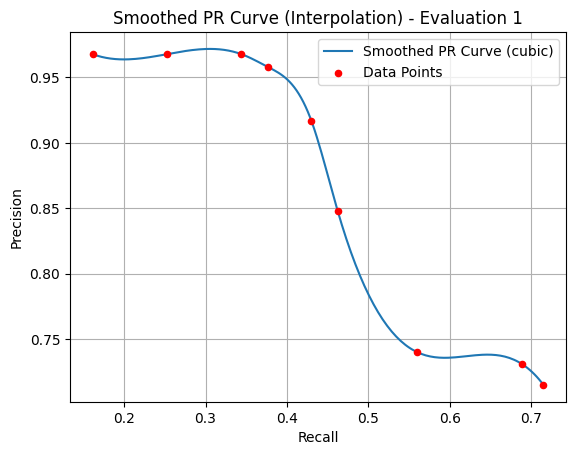

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_1:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 1")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 1")
    plt.grid(True)
    plt.legend()
    plt.show()


#### Evaluation 2

In [ ]:
# thresholds = [i / 10 for i in range(11)]
thresholds = np.linspace(0, 1, 5) # Alternative for more granular thresholds

best_ndcg_2 = -1
best_ndcg_threshold_2 = None

best_mrr_2 = -1
best_mrr_threshold_2 = None

best_f1_2 = -1
best_f1_threshold_2 = None
best_metrics_2 = None

pr_points_2 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    # num_test = len(df_test2) # Number of test cases in df_test2
    num_test = 200 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test2.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.tfidf_vector_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_2.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_2:
        best_ndcg_2 = avg_ndcg
        best_ndcg_threshold_2 = threshold

    if avg_mrr > best_mrr_2:
        best_mrr_2 = avg_mrr
        best_mrr_threshold_2 = threshold

    if f1 > best_f1_2:
        best_f1_2 = f1
        best_f1_threshold_2 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_2:.4f} (threshold={best_ndcg_threshold_2})")
print(f"Best MRR: {best_mrr_2:.4f} (threshold={best_mrr_threshold_2})")
print(f"Best F1: {best_f1_2:.4f} (threshold={best_f1_threshold_2})")


Processing Threshold 0.0: 100%|██████████| 200/200 [10:12<00:00,  3.06s/it]


Threshold: 0.0
NDCG@6: 0.6013
Precision: 0.2575
Recall: 0.5150
F1: 0.3433
MRR: 0.9563



Processing Threshold 0.25: 100%|██████████| 200/200 [10:11<00:00,  3.06s/it]


Threshold: 0.25
NDCG@6: 0.5882
Precision: 0.4438
Recall: 0.4967
F1: 0.4688
MRR: 0.9563



Processing Threshold 0.5: 100%|██████████| 200/200 [10:11<00:00,  3.06s/it]


Threshold: 0.5
NDCG@6: 0.5110
Precision: 0.8104
Recall: 0.3967
F1: 0.5326
MRR: 0.9563



Processing Threshold 0.75: 100%|██████████| 200/200 [10:11<00:00,  3.06s/it]


Threshold: 0.75
NDCG@6: 0.4726
Precision: 0.9281
Recall: 0.3517
F1: 0.5101
MRR: 0.9537



Processing Threshold 1.0: 100%|██████████| 200/200 [10:15<00:00,  3.08s/it]

Threshold: 1.0
NDCG@6: 0.4388
Precision: 0.9350
Recall: 0.3117
F1: 0.4675
MRR: 0.9350

------------
Best Results
------------
Best NDCG@6: 0.6013 (threshold=0.0)
Best MRR: 0.9563 (threshold=0.0)
Best F1: 0.5326 (threshold=0.5)


##### PR Curve

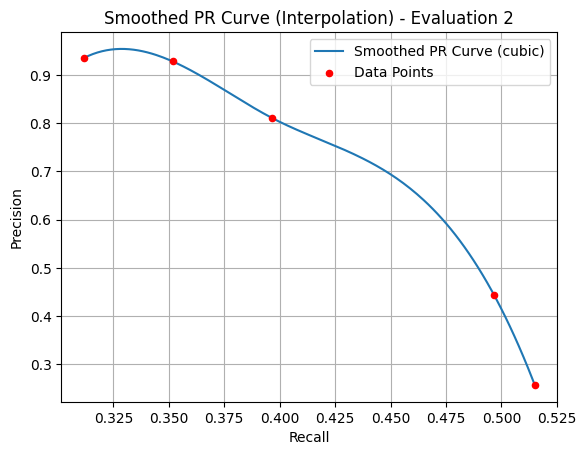

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_2:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 2")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 2")
    plt.grid(True)
    plt.legend()
    plt.show()


### BM25

#### Evaluation 1

In [ ]:
thresholds = [i / 10 for i in range(11)]
# thresholds = np.linspace(0, 1, 10) # Alternative for more granular thresholds

best_ndcg_1 = -1
best_ndcg_threshold_1 = None

best_mrr_1 = -1
best_mrr_threshold_1 = None

best_f1_1 = -1
best_f1_threshold_1 = None
best_metrics_1 = None

pr_points_1 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    num_test = len(df_test1) # Number of test cases in df_test1
    # num_test = 2 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test1.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.bm25_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_1.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_1:
        best_ndcg_1 = avg_ndcg
        best_ndcg_threshold_1 = threshold

    if avg_mrr > best_mrr_1:
        best_mrr_1 = avg_mrr
        best_mrr_threshold_1 = threshold

    if f1 > best_f1_1:
        best_f1_1 = f1
        best_f1_threshold_1 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_1:.4f} (threshold={best_ndcg_threshold_1})")
print(f"Best MRR: {best_mrr_1:.4f} (threshold={best_mrr_threshold_1})")
print(f"Best F1: {best_f1_1:.4f} (threshold={best_f1_threshold_1})")


Processing Threshold 0.0: 100%|██████████| 31/31 [02:16<00:00,  4.39s/it]


Threshold: 0.0
NDCG@6: 0.7610
Precision: 0.7097
Recall: 0.7097
F1: 0.7097
MRR: 0.9785



Processing Threshold 0.1: 100%|██████████| 31/31 [02:16<00:00,  4.41s/it]


Threshold: 0.1
NDCG@6: 0.7610
Precision: 0.7097
Recall: 0.7097
F1: 0.7097
MRR: 0.9785



Processing Threshold 0.2: 100%|██████████| 31/31 [02:17<00:00,  4.44s/it]


...

Threshold: 0.8
NDCG@6: 0.4142
Precision: 0.9785
Recall: 0.2903
F1: 0.4478
MRR: 0.9785



Processing Threshold 0.9: 100%|██████████| 31/31 [02:14<00:00,  4.33s/it]


Threshold: 0.9
NDCG@6: 0.3639
Precision: 0.9677
Recall: 0.2312
F1: 0.3732
MRR: 0.9677



Processing Threshold 1.0: 100%|██████████| 31/31 [02:16<00:00,  4.40s/it]

Threshold: 1.0
NDCG@6: 0.2928
Precision: 0.9677
Recall: 0.1613
F1: 0.2765
MRR: 0.9677

------------
Best Results
------------
Best NDCG@6: 0.7610 (threshold=0.0)
Best MRR: 0.9785 (threshold=0.0)
Best F1: 0.7106 (threshold=0.3)


##### PR Curve

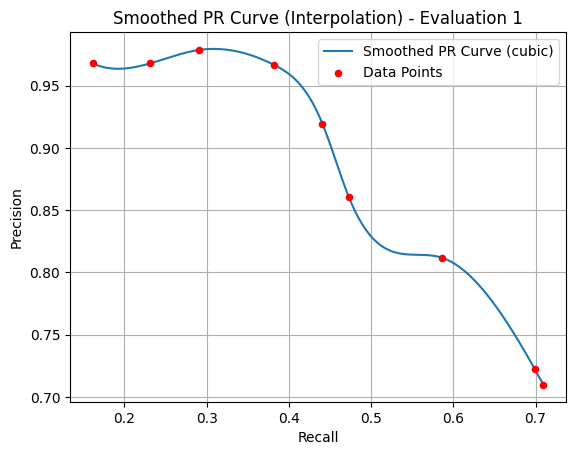

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_1:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 1")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 1")
    plt.grid(True)
    plt.legend()
    plt.show()


#### Evaluation 2

In [ ]:
# thresholds = [i / 10 for i in range(11)]
thresholds = np.linspace(0, 1, 5) # Alternative for more granular thresholds

best_ndcg_2 = -1
best_ndcg_threshold_2 = None

best_mrr_2 = -1
best_mrr_threshold_2 = None

best_f1_2 = -1
best_f1_threshold_2 = None
best_metrics_2 = None

pr_points_2 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    # num_test = len(df_test2) # Number of test cases in df_test2
    num_test = 200 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test2.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.bm25_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_2.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_2:
        best_ndcg_2 = avg_ndcg
        best_ndcg_threshold_2 = threshold

    if avg_mrr > best_mrr_2:
        best_mrr_2 = avg_mrr
        best_mrr_threshold_2 = threshold

    if f1 > best_f1_2:
        best_f1_2 = f1
        best_f1_threshold_2 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_2:.4f} (threshold={best_ndcg_threshold_2})")
print(f"Best MRR: {best_mrr_2:.4f} (threshold={best_mrr_threshold_2})")
print(f"Best F1: {best_f1_2:.4f} (threshold={best_f1_threshold_2})")


Processing Threshold 0.0: 100%|██████████| 200/200 [12:35<00:00,  3.78s/it]


Threshold: 0.0
NDCG@6: 0.6037
Precision: 0.2608
Recall: 0.5217
F1: 0.3478
MRR: 0.9671



Processing Threshold 0.25: 100%|██████████| 200/200 [12:34<00:00,  3.77s/it]


Threshold: 0.25
NDCG@6: 0.5764
Precision: 0.4753
Recall: 0.4800
F1: 0.4777
MRR: 0.9671



Processing Threshold 0.5: 100%|██████████| 200/200 [12:29<00:00,  3.75s/it]


Threshold: 0.5
NDCG@6: 0.5147
Precision: 0.8526
Recall: 0.4017
F1: 0.5461
MRR: 0.9671



Processing Threshold 0.75: 100%|██████████| 200/200 [12:30<00:00,  3.75s/it]


Threshold: 0.75
NDCG@6: 0.4761
Precision: 0.9413
Recall: 0.3533
F1: 0.5138
MRR: 0.9663



Processing Threshold 1.0: 100%|██████████| 200/200 [12:31<00:00,  3.76s/it]

Threshold: 1.0
NDCG@6: 0.4458
Precision: 0.9500
Recall: 0.3167
F1: 0.4750
MRR: 0.9500

------------
Best Results
------------
Best NDCG@6: 0.6037 (threshold=0.0)
Best MRR: 0.9671 (threshold=0.0)
Best F1: 0.5461 (threshold=0.5)


##### PR Curve

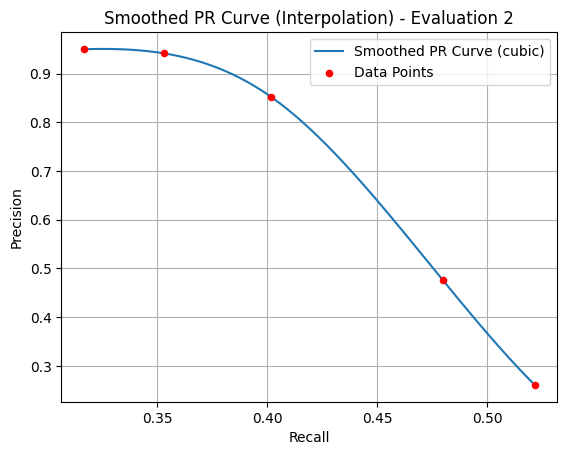

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_2:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 2")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 2")
    plt.grid(True)
    plt.legend()
    plt.show()


### BERT

#### Evaluation 1

In [ ]:
thresholds = [i / 10 for i in range(11)]
# thresholds = np.linspace(0, 1, 10) # Alternative for more granular thresholds

best_ndcg_1 = -1
best_ndcg_threshold_1 = None

best_mrr_1 = -1
best_mrr_threshold_1 = None

best_f1_1 = -1
best_f1_threshold_1 = None
best_metrics_1 = None

pr_points_1 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    num_test = len(df_test1) # Number of test cases in df_test1
    # num_test = 2 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test1.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.bert_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_1.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_1:
        best_ndcg_1 = avg_ndcg
        best_ndcg_threshold_1 = threshold

    if avg_mrr > best_mrr_1:
        best_mrr_1 = avg_mrr
        best_mrr_threshold_1 = threshold

    if f1 > best_f1_1:
        best_f1_1 = f1
        best_f1_threshold_1 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_1:.4f} (threshold={best_ndcg_threshold_1})")
print(f"Best MRR: {best_mrr_1:.4f} (threshold={best_mrr_threshold_1})")
print(f"Best F1: {best_f1_1:.4f} (threshold={best_f1_threshold_1})")


Processing Threshold 0.0: 100%|██████████| 31/31 [01:44<00:00,  3.37s/it]


Threshold: 0.0
NDCG@6: 0.6921
Precision: 0.6344
Recall: 0.6344
F1: 0.6344
MRR: 0.9839



Processing Threshold 0.1: 100%|██████████| 31/31 [01:46<00:00,  3.44s/it]


Threshold: 0.1
NDCG@6: 0.6921
Precision: 0.6344
Recall: 0.6344
F1: 0.6344
MRR: 0.9839



Processing Threshold 0.2: 100%|██████████| 31/31 [01:44<00:00,  3.36s/it]


...

Threshold: 0.8
NDCG@6: 0.5025
Precision: 0.8495
Recall: 0.3871
F1: 0.5318
MRR: 0.9839



Processing Threshold 0.9: 100%|██████████| 31/31 [01:43<00:00,  3.32s/it]


Threshold: 0.9
NDCG@6: 0.3745
Precision: 0.9140
Recall: 0.2419
F1: 0.3826
MRR: 0.9677



Processing Threshold 1.0: 100%|██████████| 31/31 [01:44<00:00,  3.36s/it]

Threshold: 1.0
NDCG@6: 0.2928
Precision: 0.9677
Recall: 0.1613
F1: 0.2765
MRR: 0.9677

------------
Best Results
------------
Best NDCG@6: 0.6921 (threshold=0.0)
Best MRR: 0.9839 (threshold=0.0)
Best F1: 0.6412 (threshold=0.7)


##### PR Curve

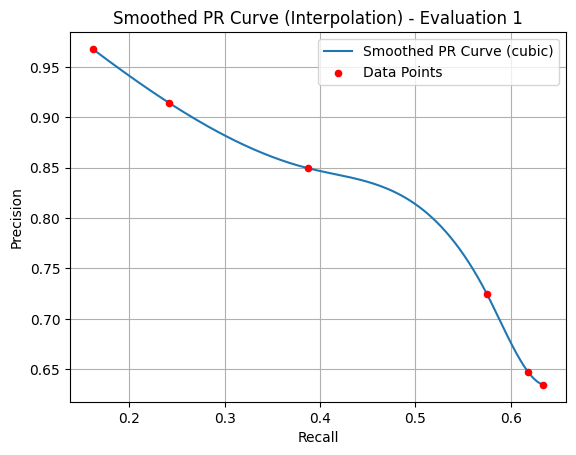

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_1:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 1")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 1")
    plt.grid(True)
    plt.legend()
    plt.show()


In this work, ROC AUC is not an appropriate evaluation metric because the task is formulated as a ranking-based recommendation problem rather than a binary classification problem. First, the dataset is highly imbalanced, where each query has only a small number of relevant (positive) items among a very large pool of non-relevant (negative) items. This causes ROC AUC to be overly optimistic, as the large number of true negatives can dominate the evaluation and obscure the model’s actual ability to identify relevant items. Second, ROC AUC evaluates the model’s overall ranking performance across all items, but it does not emphasize the quality of the top-ranked results, which are the most important in recommendation scenarios. Third, ROC AUC requires a complete scoring over all candidate items, whereas our system is based on a threshold-based retrieval approach that only returns a subset of results. Therefore, ROC AUC does not align well with our system design or evaluation goals. Instead, metrics such as NDCG@K, Precision@K, Recall@K, and MRR are more suitable, as they better capture the effectiveness of ranking and the quality of top recommendations.

#### Evaluation 2

In [ ]:
# thresholds = [i / 10 for i in range(11)]
thresholds = np.linspace(0, 1, 5) # Alternative for more granular thresholds

best_ndcg_2 = -1
best_ndcg_threshold_2 = None

best_mrr_2 = -1
best_mrr_threshold_2 = None

best_f1_2 = -1
best_f1_threshold_2 = None
best_metrics_2 = None

pr_points_2 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    # num_test = len(df_test2) # Number of test cases in df_test2
    num_test = 200 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test2.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.bert_search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_2.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_2:
        best_ndcg_2 = avg_ndcg
        best_ndcg_threshold_2 = threshold

    if avg_mrr > best_mrr_2:
        best_mrr_2 = avg_mrr
        best_mrr_threshold_2 = threshold

    if f1 > best_f1_2:
        best_f1_2 = f1
        best_f1_threshold_2 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_2:.4f} (threshold={best_ndcg_threshold_2})")
print(f"Best MRR: {best_mrr_2:.4f} (threshold={best_mrr_threshold_2})")
print(f"Best F1: {best_f1_2:.4f} (threshold={best_f1_threshold_2})")


Processing Threshold 0.0: 100%|██████████| 200/200 [11:11<00:00,  3.36s/it]


Threshold: 0.0
NDCG@6: 0.4843
Precision: 0.2033
Recall: 0.4067
F1: 0.2711
MRR: 0.8483



Processing Threshold 0.25: 100%|██████████| 200/200 [11:08<00:00,  3.34s/it]


Threshold: 0.25
NDCG@6: 0.4843
Precision: 0.2033
Recall: 0.4067
F1: 0.2711
MRR: 0.8483



Processing Threshold 0.5: 100%|██████████| 200/200 [11:11<00:00,  3.36s/it]


Threshold: 0.5
NDCG@6: 0.4803
Precision: 0.2761
Recall: 0.4000
F1: 0.3267
MRR: 0.8483



Processing Threshold 0.75: 100%|██████████| 200/200 [11:11<00:00,  3.36s/it]


Threshold: 0.75
NDCG@6: 0.4422
Precision: 0.6358
Recall: 0.3467
F1: 0.4487
MRR: 0.8470



Processing Threshold 1.0: 100%|██████████| 200/200 [11:14<00:00,  3.37s/it]

Threshold: 1.0
NDCG@6: 0.3848
Precision: 0.8200
Recall: 0.2733
F1: 0.4100
MRR: 0.8200

------------
Best Results
------------
Best NDCG@6: 0.4843 (threshold=0.0)
Best MRR: 0.8483 (threshold=0.0)
Best F1: 0.4487 (threshold=0.75)


##### PR Curve

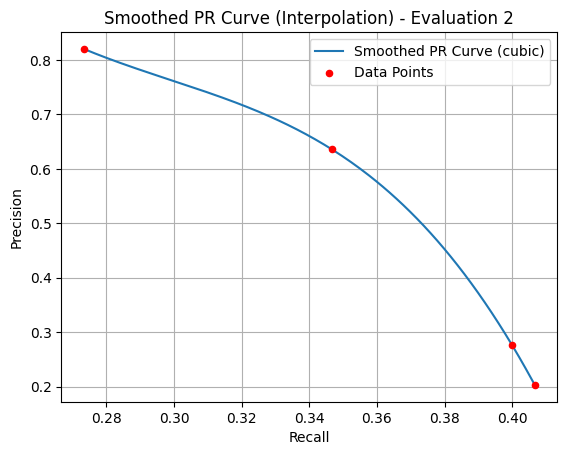

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_2:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 2")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 2")
    plt.grid(True)
    plt.legend()
    plt.show()


### Hybrid Search

#### Evaluation 1

In [17]:
thresholds = [i / 10 for i in range(11)]
# thresholds = np.linspace(0, 1, 10) # Alternative for more granular thresholds

best_ndcg_1 = -1
best_ndcg_threshold_1 = None

best_mrr_1 = -1
best_mrr_threshold_1 = None

best_f1_1 = -1
best_f1_threshold_1 = None
best_metrics_1 = None

pr_points_1 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    num_test = len(df_test1) # Number of test cases in df_test1
    # num_test = 2 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test1.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_1.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_1:
        best_ndcg_1 = avg_ndcg
        best_ndcg_threshold_1 = threshold

    if avg_mrr > best_mrr_1:
        best_mrr_1 = avg_mrr
        best_mrr_threshold_1 = threshold

    if f1 > best_f1_1:
        best_f1_1 = f1
        best_f1_threshold_1 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_1:.4f} (threshold={best_ndcg_threshold_1})")
print(f"Best MRR: {best_mrr_1:.4f} (threshold={best_mrr_threshold_1})")
print(f"Best F1: {best_f1_1:.4f} (threshold={best_f1_threshold_1})")


Processing Threshold 0.0: 100%|██████████| 31/31 [02:43<00:00,  5.28s/it]


Threshold: 0.0
NDCG@6: 0.7711
Precision: 0.7204
Recall: 0.7204
F1: 0.7204
MRR: 0.9785



Processing Threshold 0.1: 100%|██████████| 31/31 [02:47<00:00,  5.40s/it]


Threshold: 0.1
NDCG@6: 0.7711
Precision: 0.7204
Recall: 0.7204
F1: 0.7204
MRR: 0.9785



Processing Threshold 0.2: 100%|██████████| 31/31 [02:42<00:00,  5.24s/it]


...

Threshold: 0.8
NDCG@6: 0.4397
Precision: 0.9785
Recall: 0.3172
F1: 0.4791
MRR: 0.9785



Processing Threshold 0.9: 100%|██████████| 31/31 [02:49<00:00,  5.48s/it]


Threshold: 0.9
NDCG@6: 0.3847
Precision: 0.9677
Recall: 0.2527
F1: 0.4007
MRR: 0.9677



Processing Threshold 1.0: 100%|██████████| 31/31 [02:49<00:00,  5.47s/it]

Threshold: 1.0
NDCG@6: 0.2928
Precision: 0.9677
Recall: 0.1613
F1: 0.2765
MRR: 0.9677

------------
Best Results
------------
Best NDCG@6: 0.7711 (threshold=0.0)
Best MRR: 0.9785 (threshold=0.0)
Best F1: 0.7204 (threshold=0.0)


##### PR Curve

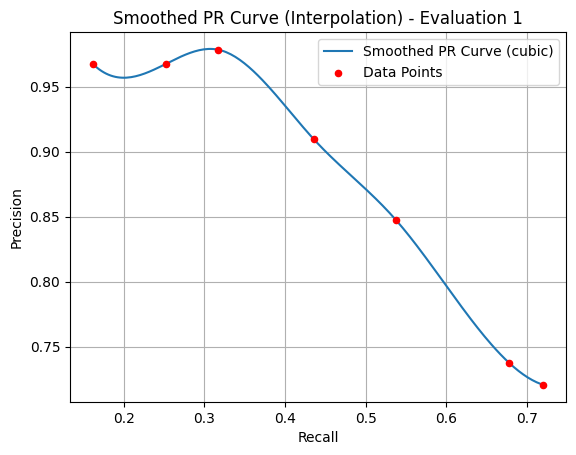

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_1:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 1")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 1")
    plt.grid(True)
    plt.legend()
    plt.show()


#### Evaluation 2

In [19]:
# thresholds = [i / 10 for i in range(11)]
thresholds = np.linspace(0, 1, 5) # Alternative for more granular thresholds

best_ndcg_2 = -1
best_ndcg_threshold_2 = None

best_mrr_2 = -1
best_mrr_threshold_2 = None

best_f1_2 = -1
best_f1_threshold_2 = None
best_metrics_2 = None

pr_points_2 = [] # Stores (recall, precision) pairs for PR curve plotting

for threshold in thresholds:
    total_ndcg = 0
    total_precision = 0
    total_recall = 0
    total_mrr = 0

    # num_test = len(df_test2) # Number of test cases in df_test2
    num_test = 200 # For quick testing, uncomment and set to a small number
    k = 6 # Number of top recommendations to consider

    for i in tqdm(range(num_test), desc=f"Processing Threshold {threshold}"):
        test = df_test2.loc[i]
        original_id = test['original_index']
        fulltext = df_posts.loc[original_id]['lemmatized_full_text']

        # Extract ground truth recommended indices, filtering out non-integer values
        groundtruths = [idx for idx in test.values if isinstance(idx, np.int64)]

        # Perform hybrid search using the current threshold
        hybrid_results = recsys.search(
            fulltext,
            threshold=threshold,
            top_n=k,
            apply_rule=True
        )

        # Extract IDs of the recommended articles
        answers = [r['id'] for r in hybrid_results]

        # Calculate hits (intersection of answers and groundtruths)
        hits = len(set(answers) & set(groundtruths))

        # Calculate Precision
        precision = hits / len(answers) if len(answers) > 0 else 0
        total_precision += precision

        # Calculate Recall
        recall = hits / len(groundtruths) if len(groundtruths) > 0 else 0
        total_recall += recall

        # Calculate NDCG
        total_ndcg += ndcg_at_k(answers, groundtruths, k=k)

        # Calculate Mean Reciprocal Rank (MRR)
        rr = 0
        for rank, a in enumerate(answers, start=1):
            if a in groundtruths:
                rr = 1 / rank
                break
        total_mrr += rr

    # Calculate average metrics for the current threshold
    avg_precision = total_precision / num_test
    avg_recall = total_recall / num_test
    avg_ndcg = total_ndcg / num_test
    avg_mrr = total_mrr / num_test

    # Calculate F1-score
    f1 = (
        2 * avg_precision * avg_recall / (avg_precision + avg_recall)
        if (avg_precision + avg_recall) > 0 else 0
    )

    # Store (recall, precision) point for the PR curve
    pr_points_2.append((avg_recall, avg_precision))

    # Update best metrics if current threshold yields better results
    if avg_ndcg > best_ndcg_2:
        best_ndcg_2 = avg_ndcg
        best_ndcg_threshold_2 = threshold

    if avg_mrr > best_mrr_2:
        best_mrr_2 = avg_mrr
        best_mrr_threshold_2 = threshold

    if f1 > best_f1_2:
        best_f1_2 = f1
        best_f1_threshold_2 = threshold

    print(f"Threshold: {threshold}")
    print(f"NDCG@{k}: {avg_ndcg:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MRR: {avg_mrr:.4f}")
    print()

print("------------")
print("Best Results")
print("------------")
print(f"Best NDCG@{k}: {best_ndcg_2:.4f} (threshold={best_ndcg_threshold_2})")
print(f"Best MRR: {best_mrr_2:.4f} (threshold={best_mrr_threshold_2})")
print(f"Best F1: {best_f1_2:.4f} (threshold={best_f1_threshold_2})")


Processing Threshold 0.0: 100%|██████████| 200/200 [15:50<00:00,  4.75s/it]


Threshold: 0.0
NDCG@6: 0.5856
Precision: 0.2550
Recall: 0.5100
F1: 0.3400
MRR: 0.9218



Processing Threshold 0.25: 100%|██████████| 200/200 [15:55<00:00,  4.78s/it]


Threshold: 0.25
NDCG@6: 0.5847
Precision: 0.2799
Recall: 0.5083
F1: 0.3610
MRR: 0.9218



Processing Threshold 0.5: 100%|██████████| 200/200 [15:54<00:00,  4.77s/it]


Threshold: 0.5
NDCG@6: 0.5261
Precision: 0.6620
Recall: 0.4283
F1: 0.5201
MRR: 0.9218



Processing Threshold 0.75: 100%|██████████| 200/200 [15:43<00:00,  4.72s/it]


Threshold: 0.75
NDCG@6: 0.4543
Precision: 0.8714
Recall: 0.3400
F1: 0.4891
MRR: 0.9177



Processing Threshold 1.0: 100%|██████████| 200/200 [15:39<00:00,  4.70s/it]

Threshold: 1.0
NDCG@6: 0.4200
Precision: 0.8950
Recall: 0.2983
F1: 0.4475
MRR: 0.8950

------------
Best Results
------------
Best NDCG@6: 0.5856 (threshold=0.0)
Best MRR: 0.9218 (threshold=0.0)
Best F1: 0.5201 (threshold=0.5)


##### PR Curve

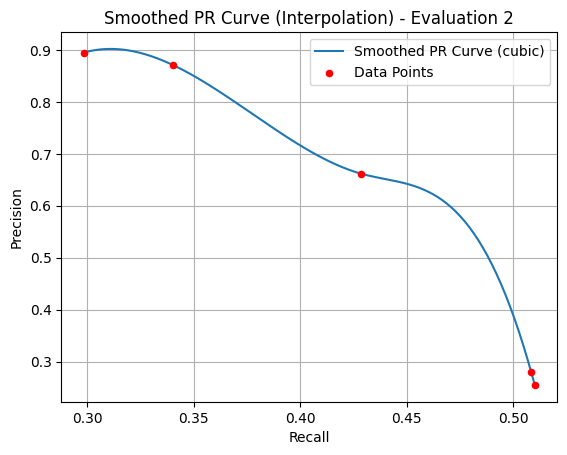

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Collect all unique recall-precision pairs.
# A dictionary is used to get the maximum precision for each unique recall value.
pr_dict = {}
for r, p in pr_points_2:
    # Store the maximum precision for a given recall
    pr_dict[r] = max(pr_dict.get(r, 0.0), p)

# Convert the dictionary back to sorted lists of recall and precision
sorted_recalls = np.array(sorted(pr_dict.keys()))
sorted_precisions = np.array([pr_dict[r] for r in sorted_recalls])

# Check if there are enough unique points for interpolation
if len(sorted_recalls) < 2:
    print("Not enough unique recall points to plot a meaningful PR curve.")
    if len(sorted_recalls) == 1:
        plt.figure()
        plt.scatter(sorted_recalls, sorted_precisions, color='blue')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("PR Curve (Single Point) - Evaluation 2")
        plt.grid(True)
        plt.show()
else:
    # Determine interpolation kind based on number of points available
    kind = 'cubic'
    if len(sorted_recalls) < 4:
        kind = 'linear' # Fallback to linear if not enough points for cubic interpolation

    # Create an interpolation function
    # Use fill_value="extrapolate" to handle cases where recall_smooth goes slightly beyond sorted_recalls range
    f = interp1d(sorted_recalls, sorted_precisions, kind=kind, fill_value="extrapolate")

    # Generate a smoother range of recall values for plotting
    recall_smooth = np.linspace(min(sorted_recalls), max(sorted_recalls), 200)
    # Get corresponding precision values from the interpolated function
    precision_smooth = f(recall_smooth)

    # Plotting the smoothed PR curve
    plt.figure()
    plt.plot(recall_smooth, precision_smooth, label=f'Smoothed PR Curve ({kind})')
    # Plot the original data points for reference
    plt.scatter(sorted_recalls, sorted_precisions, color='red', s=20, zorder=5, label='Data Points')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Smoothed PR Curve (Interpolation) - Evaluation 2")
    plt.grid(True)
    plt.legend()
    plt.show()
